required modules

In [ ]:
!pip install stanza
!pip install mysql-connector-python
!pip install networkx
!pip install matplotlib
!pip install transformers torch
!pip install requests
!pip install openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 23.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12

setting ai4/bharat

In [ ]:
%%capture
!git clone https://github.com/AI4Bharat/IndicTrans2.git

In [ ]:
%%capture
%cd /content/IndicTrans2/huggingface_interface

In [ ]:
%%capture
!python3 -m pip install nltk sacremoses pandas regex mock transformers>=4.33.2 mosestokenizer
!python3 -c "import nltk; nltk.download('punkt')"
!python3 -m pip install bitsandbytes scipy accelerate datasets
!python3 -m pip install sentencepiece

!git clone https://github.com/VarunGumma/IndicTransToolkit.git
%cd IndicTransToolkit
!python3 -m pip install --editable ./
%cd ..

In [ ]:
# Restart runtime in Google Colab
import os
os.kill(os.getpid(), 9)


In [ ]:
import torch
from transformers import AutoModelForSeq2SeqLM, BitsAndBytesConfig, AutoTokenizer
from IndicTransToolkit import IndicProcessor

BATCH_SIZE = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
quantization = None

In [ ]:
# function for ai4/bharat to change san to eng
def initialize_model_and_tokenizer(ckpt_dir, quantization):
    if quantization == "4-bit":
        qconfig = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch.bfloat16,
        )
    elif quantization == "8-bit":
        qconfig = BitsAndBytesConfig(
            load_in_8bit=True,
            bnb_8bit_use_double_quant=True,
            bnb_8bit_compute_dtype=torch.bfloat16,
        )
    else:
        qconfig = None

    tokenizer = AutoTokenizer.from_pretrained(ckpt_dir, trust_remote_code=True)
    model = AutoModelForSeq2SeqLM.from_pretrained(
        ckpt_dir,
        trust_remote_code=True,
        low_cpu_mem_usage=True,
        quantization_config=qconfig,
    )

    if qconfig == None:
        model = model.to(DEVICE)
        if DEVICE == "cuda":
            model.half()

    model.eval()

    return tokenizer, model


def batch_translate(input_sentences, src_lang, tgt_lang, model, tokenizer, ip):
    translations = []
    for i in range(0, len(input_sentences), BATCH_SIZE):
        batch = input_sentences[i : i + BATCH_SIZE]

        # Preprocess the batch and extract entity mappings
        batch = ip.preprocess_batch(batch, src_lang=src_lang, tgt_lang=tgt_lang)

        # Tokenize the batch and generate input encodings
        inputs = tokenizer(
            batch,
            truncation=True,
            padding="longest",
            return_tensors="pt",
            return_attention_mask=True,
        ).to(DEVICE)

        # Generate translations using the model
        with torch.no_grad():
            generated_tokens = model.generate(
                **inputs,
                use_cache=True,
                min_length=0,
                max_length=256,
                num_beams=5,
                num_return_sequences=1,
            )

        # Decode the generated tokens into text

        with tokenizer.as_target_tokenizer():
            generated_tokens = tokenizer.batch_decode(
                generated_tokens.detach().cpu().tolist(),
                skip_special_tokens=True,
                clean_up_tokenization_spaces=True,
            )

        # Postprocess the translations, including entity replacement
        translations += ip.postprocess_batch(generated_tokens, lang=tgt_lang)

        del inputs
        torch.cuda.empty_cache()

    return translations


for my sql in colab


In [ ]:
# Step 1: Uninstall MySQL completely
!sudo apt-get purge mysql-server mysql-client mysql-common mysql-server-core-* mysql-client-core-*
!sudo apt-get autoremove -y
!sudo apt-get autoclean -y

# Step 2: Clean up any residual packages
!sudo rm -rf /etc/mysql /var/lib/mysql /var/log/mysql /var/run/mysqld
!sudo deluser mysql
!sudo delgroup mysql

# Step 3: Reinstall MySQL
!sudo apt-get update
!sudo apt-get install -y mysql-server mysql-client


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'mysql-server-core-5.5' for glob 'mysql-server-core-*'
Note, selecting 'mysql-server-core-5.6' for glob 'mysql-server-core-*'
Note, selecting 'mysql-server-core-5.7' for glob 'mysql-server-core-*'
Note, selecting 'mysql-server-core-8.0' for glob 'mysql-server-core-*'
Package 'mysql-server-core-5.7' is not installed, so not removed
Package 'mysql-server-core-5.5' is not installed, so not removed
Package 'mysql-server-core-5.6' is not installed, so not removed
Note, selecting 'mysql-client-core-5.5' for glob 'mysql-client-core-*'
Note, selecting 'mysql-client-core-5.6' for glob 'mysql-client-core-*'
Note, selecting 'mysql-client-core-5.7' for glob 'mysql-client-core-*'
Note, selecting 'mysql-client-core-8.0' for glob 'mysql-client-core-*'
Package 'mysql-client-core-5.7' is not installed, so not removed
Package 'mysql-client-core-5.5' is not installed, so not removed
Package 'm

In [ ]:
!sudo service mysql start


 * Starting MySQL database server mysqld
su: warning: cannot change directory to /nonexistent: No such file or directory
   ...done.


In [ ]:
!sudo mysql -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY 'root'; FLUSH PRIVILEGES;"





In [ ]:
!sudo mysql -u root -proot -e "SHOW DATABASES;"


mysql: [Warning] Using a password on the command line interface can be insecure.
+--------------------+
| Database           |
+--------------------+
| information_schema |
| mysql              |
| performance_schema |
| sys                |
+--------------------+


In [ ]:
!sudo mysql -u root -proot -e "CREATE DATABASE sanskrit_wordnet;"


mysql: [Warning] Using a password on the command line interface can be insecure.


In [ ]:
!sudo mysql -u root -proot -e "SHOW DATABASES;"


mysql: [Warning] Using a password on the command line interface can be insecure.
+--------------------+
| Database           |
+--------------------+
| information_schema |
| mysql              |
| performance_schema |
| sanskrit_wordnet   |
| sys                |
+--------------------+


In [ ]:
!sudo mysql -u root -proot sanskrit_wordnet < sanskrit.sql


mysql: [Warning] Using a password on the command line interface can be insecure.


In [ ]:
!sudo mysql -u root -proot -e "USE sanskrit_wordnet; SHOW TABLES;SELECT * FROM synset_table LIMIT 5;"


mysql: [Warning] Using a password on the command line interface can be insecure.
+----------------------------+
| Tables_in_sanskrit_wordnet |
+----------------------------+
| synset_table               |
+----------------------------+
+-----------+------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Main Code

till now we have done it so far

new integrated code

In [ ]:
import mysql.connector
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib.colors as mcolors
import stanza
import numpy as np
from transformers import AutoTokenizer, pipeline


# Initialize Stanza (Sanskrit Processing)
stanza.download("sa")
nlp = stanza.Pipeline("sa", processors="tokenize")
# Database Connection
db_config = {
    "host": "127.0.0.1",
    "user": "root",
    "password": "root",
    "database": "sanskrit_wordnet"
}
conn = mysql.connector.connect(**db_config)
cursor = conn.cursor(dictionary=True)
from urllib.parse import urlparse
import time
# ---------- Font Setup ----------
font_path = "/content/NotoSansDevanagari-VariableFont_wdth,wght.ttf"
font_manager.fontManager.addfont(font_path)
plt.rc('font', family='Noto Sans Devanagari')  # Set the font globally for Matplotlib




INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Downloading default packages for language: sa (Sanskrit) ...


INFO:stanza:Downloaded file to /root/stanza_resources/sa/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: sa (Sanskrit):
| Processor | Package |
-----------------------
| tokenize  | vedic   |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Done loading processors!


In [ ]:
lemma_dict = {
    "नमो": "नमस्",
    "नमः": "नमस्",
    "नमामि": "नमस्",
    "भविता": "भू",
    "भूयः": "भू",
    "अहम्": "अस्मद्",
    "त्वम्": "युष्मद्",
    "सः": "तद्",
    "सा": "तद्",
    "तत्": "तद्",
    "एषः": "एतद्",
    "एषा": "एतद्",
    "एतत्": "एतद्",
    "कृष्णाय": "कृष्ण",
    "वासुदेवाय": "वासुदेव",
    "हरये": "हरि",
    "गोविन्दाय": "गोविन्द",
    "प्रणतः": "प्रणत",
    "अर्जुनाय": "अर्जुन",
    "रामाय": "राम",
    "शिवाय": "शिव",
    "विष्णोः": "विष्णुः",
    "देवाय": "देव",
    "हरिः": "हरि",
    "पार्थ": "अर्जुन",
    "माम्": "अहम्",
    "त्वां": "त्वम्",
    "दत्तात्रेयाय": "दत्तात्रेय",
    "वरदाय": "वरद",
    "सर्वशक्तिमते": "सर्वशक्तिमान्",
    "श्रीकृष्णाय": "श्रीकृष्ण",
    "गुरवे": "गुरु",
    "वन्दे": "वन्द्",
    "जगन्नाथाय": "जगन्नाथ",
    "चिन्मये": "चिन्मय",
    "धनंजय": "अर्जुन",
    "माधवाय": "माधव",
    "महेशाय": "महेश",
    "पद्मनाभाय": "पद्मनाभ",
    "नारायणाय": "नारायण",
    "वराय": "वर",
    "सर्वेशाय": "सर्वेश",
    "लोकनाथाय": "लोकनाथ",
    "राघवे": "राघव",
    "परमात्मने": "परमात्मा",
    "दोषनिधे" : "दोषनिधि",
    "ह्येको" : "ह्यः",
    "पाद":"पादः",
    "आत्मन्":"स्वः","गृहीत्वा": "गृहीत", "करे": "करः", "कृष्णम": "कृष्ण", "उपालभ्य": "उपालभ्", "हितैषिणी": "हितैषिन्",
    "कृष्णाय": "कृष्ण", "विष्णोः": "विष्णुः", "श्रवणं": "श्रवणम्", "कीर्तनं": "कीर्तनम्"
}


# ---------------------------**FINAL CODE**-------------------------------

In Proccess
trying to get synonyms

In [ ]:
import re
# Utility function to replace final dot with 'म्'
def replace_final_dot_with_half_m(text):
    return re.sub(r'ं$', 'म्', text)

# Lemma extraction function
def extract_lemma(word, lemma_dict):
    """
    Extracts the lemma for a given word.
    1. If the word is found in the provided dictionary, return the corresponding lemma.
    2. If the word ends with 'ं.', replace it with 'म्'.
    3. Otherwise, return the original word.

    Args:
        word (str): The input Sanskrit word.
        lemma_dictionary (dict): Dictionary containing known lemma mappings.

    Returns:
        str: The extracted lemma.
    """
    if word in lemma_dict:
        return lemma_dict[word]
    elif word.endswith("ं"):
        return replace_final_dot_with_half_m(word)
    else:
        return word


without llm the wsd down here

Device set to use cpu


Step 1 => Input Sanskrit Sentence:
सा गृहीत्वा करे कृष्णम उपालभ्य हितैषिणी

Step 2 => Preprocessing the verse (Tokenization, Lemmatization, Stop Word Removal):
Tokens after stop word removal: ['गृहीत्वा', 'करे', 'कृष्णम', 'उपालभ्य', 'हितैषिणी']
Sanskrit Lemmas in Devanagari: ['गृहीत', 'करः', 'कृष्ण', 'उपालभ्', 'हितैषिन्']

Step 3 => Extracting Word Relations (Synsets, Gloss, Category):
गृहीत: Synset = गृहीत, अभिगृहीत, परिगृहीत, संगृहीत, ग्रस्त, ग्रथित, प्रलब्ध, आत्त, आदत्त, आक्षिप्त, स्वांकृत, समादत्त, निगृहीत , Gloss = यत् धृतम्। ; "गृहीतः मनुष्यः बन्धनात् पलायितः।", Category = adjective
करः: Synset = नृपांशः, राजस्वम्, करः, कारः, बलिः, आयः , Gloss = राज्ञे सर्वकाराय वा शुल्करूपेण जायमाना प्राप्तिः। ; "केचित् राज्ञः नृपांशः प्रजायाः हितार्थम् उपयुज्यन्ते।/प्रजानामेव भूत्यर्थं स ताभ्यो बलिम् अग्रहीत्।", Category = noun
कृष्ण: Synset = कृष्णवर्णीय, श्वेतेतर, कृष्ण, Gloss = यः मानवः श्वेतवर्णीयः नास्ति ।;"आङ्ग्लाः कृष्णवर्णीयैः सह दुर्वर्तनं कृतवन्तः।", Category = adjective
उपालभ्: Synse

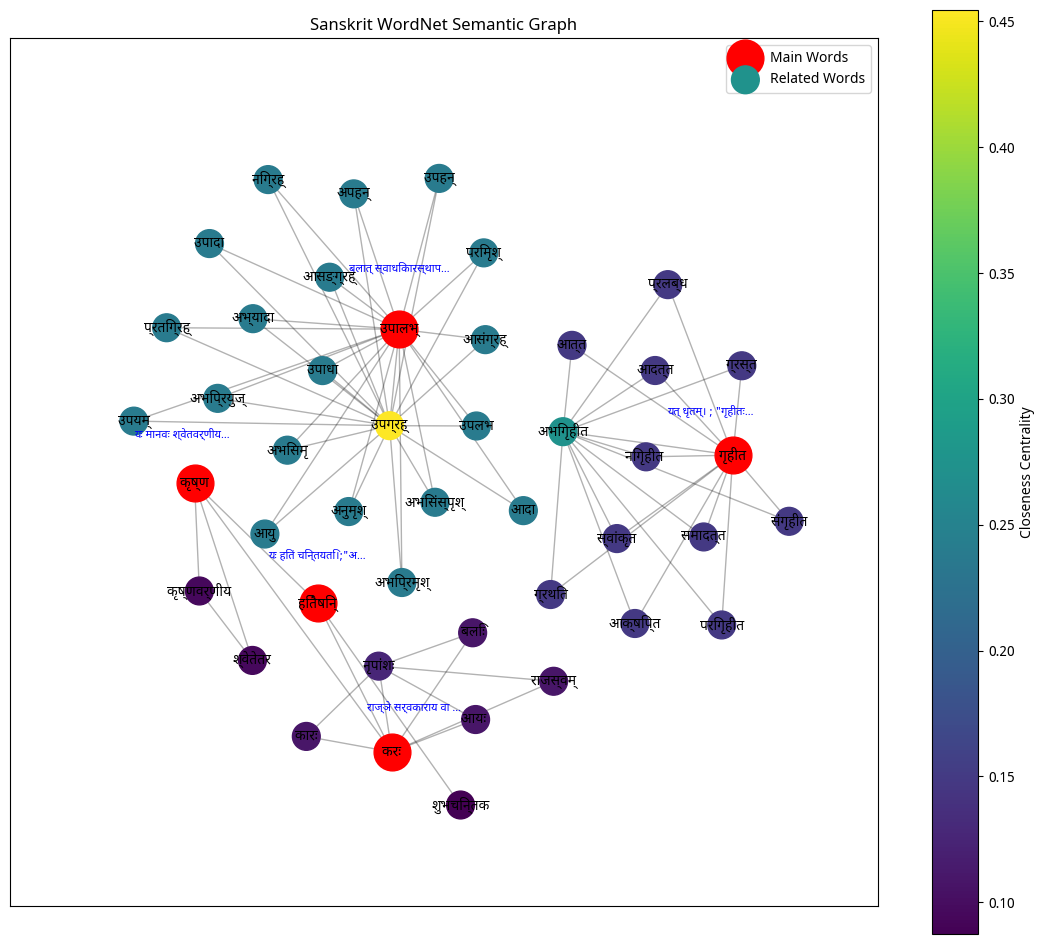

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import mysql.connector
import numpy as np
from transformers import pipeline  # For BERT-based sentiment analysis

# Assume these are defined elsewhere in your codebase
# from your_translation_module import initialize_model_and_tokenizer, IndicProcessor, batch_translate

# Initialize the translation model
indic_en_ckpt_dir = "ai4bharat/indictrans2-indic-en-1B"
indic_en_tokenizer, indic_en_model = initialize_model_and_tokenizer(indic_en_ckpt_dir, quantization=None)
ip = IndicProcessor(inference=True)
src_lang, tgt_lang = "san_Deva", "eng_Latn"

# Initialize BERT-based sentiment analysis
sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# Translation Corrections (General, not specific)
translated_correction = {}

# Correction Dictionary for specific translation fixes
correction_dict = {
    "The satellite's": "rebuked"
}

# Database Connection
db_config = {
    "host": "127.0.0.1",
    "user": "root",
    "password": "root",
    "database": "sanskrit_wordnet"
}
conn = mysql.connector.connect(**db_config)
cursor = conn.cursor(dictionary=True)

# Step 1: Input Sanskrit Sentence (Not explicitly in the flowchart but implied)
sanskrit_sentence = "सा गृहीत्वा करे कृष्णम उपालभ्य हितैषिणी"
print("Step 1 => Input Sanskrit Sentence:")
print(sanskrit_sentence)

# Step 2: Preprocessing the verse
tokens = sanskrit_sentence.split()
stop_words = {"च", "व", "इति", "यः", "सः", "सा", "तत्", "एषः", "एषा", "एतत्"}
tokens = [token for token in tokens if token not in stop_words]

# Lemma Dictionary
lemma_dict = {
    "गृहीत्वा": "गृहीत", "करे": "करः", "कृष्णम": "कृष्ण", "उपालभ्य": "उपालभ्", "हितैषिणी": "हितैषिन्",
    "कृष्णाय": "कृष्ण", "विष्णोः": "विष्णुः", "श्रवणं": "श्रवणम्", "कीर्तनं": "कीर्तनम्"
}

def extract_lemma(word, lemma_dict):
    return lemma_dict.get(word, word)

sanskrit_lemmas = [extract_lemma(word, lemma_dict) for word in tokens]
print("\nStep 2 => Preprocessing the verse (Tokenization, Lemmatization, Stop Word Removal):")
print("Tokens after stop word removal:", tokens)
print("Sanskrit Lemmas in Devanagari:", sanskrit_lemmas)

# Step 3: Extracting Word Relations
word_relations = {}

def compute_gloss_overlap(gloss1, gloss2, keyword_weights=None):
    gloss1_words = set(gloss1.split())
    gloss2_words = set(gloss2.split())
    overlap = gloss1_words.intersection(gloss2_words)
    score = len(overlap) * 2
    if keyword_weights:
        for word in overlap:
            score += keyword_weights.get(word, 0) * 3
    union = gloss1_words.union(gloss2_words)
    jaccard = len(overlap) / len(union) if union else 0
    return score + jaccard * 10

def select_sense(word, context_words, word_relations, keyword_weights=None):
    senses = word_relations.get(word, [])
    if not senses:
        cursor.execute(f"SELECT synset, gloss, category FROM synset_table WHERE FIND_IN_SET('{word}', REPLACE(synset, ' ', '')) > 0;")
        senses = cursor.fetchall()

    if not senses:
        return None, None

    context_gloss = " ".join(s["gloss"] for w in context_words if w in word_relations for s in word_relations[w])
    for w in context_words:
        if w not in word_relations:
            cursor.execute(f"SELECT gloss FROM synset_table WHERE FIND_IN_SET('{w}', REPLACE(synset, ' ', '')) > 0;")
            results = cursor.fetchall()
            if results:
                gloss = results[0]["gloss"].decode('utf-8') if isinstance(results[0]["gloss"], bytes) else results[0]["gloss"]
                context_gloss += " " + gloss

    devotional_keywords = {"देवता", "भक्ति", "ईश्वर", "उपासक", "उपास्य", "सेवा", "हित", "कृष्ण", "नारायणः"}
    best_sense, best_score = None, -1
    for sense in senses:
        gloss = sense["gloss"].decode('utf-8') if isinstance(sense["gloss"], bytes) else sense["gloss"]
        score = compute_gloss_overlap(gloss, context_gloss, keyword_weights)
        if any(kw in gloss for kw in devotional_keywords):
            score += 50
        if score > best_score:
            best_score = score
            best_sense = sense

    return best_sense, best_score

# Graph Construction
G = nx.Graph()
main_nodes = set()
selected_senses = {}
keyword_weights = {"देवता": 5, "भक्ति": 5, "ईश्वर": 3, "उपासक": 2, "उपास्य": 2, "हित": 5, "कृष्ण": 5}

for word in sanskrit_lemmas:
    G.add_node(word, category="MainWord")
    main_nodes.add(word)

    context_words = [w for w in sanskrit_lemmas if w != word]
    best_sense, score = select_sense(word, context_words, word_relations, keyword_weights)
    if best_sense:
        best_sense["gloss"] = best_sense["gloss"].decode('utf-8') if isinstance(best_sense["gloss"], bytes) else best_sense["gloss"]
        best_sense["synset"] = best_sense["synset"].decode('utf-8') if isinstance(best_sense["synset"], bytes) else best_sense["synset"]
        selected_senses[word] = best_sense
    else:
        continue

    relation_weights = defaultdict(float)
    gloss_map = {}
    senses = [best_sense]
    for sense in senses:
        gloss = sense["gloss"]
        synset = sense["synset"]
        synset_words = synset.split(", ")
        gloss_map[word] = gloss
        for synonym in synset_words:
            if synonym != word:
                syn_score = 3.0
                cursor.execute(f"SELECT gloss FROM synset_table WHERE FIND_IN_SET('{synonym}', REPLACE(synset, ' ', '')) > 0;")
                syn_results = cursor.fetchall()
                if syn_results:
                    syn_gloss = syn_results[0]["gloss"].decode('utf-8') if isinstance(syn_results[0]["gloss"], bytes) else syn_results[0]["gloss"]
                    overlap = compute_gloss_overlap(syn_gloss, gloss, keyword_weights)
                    syn_score += overlap / 5.0
                relation_weights[synonym] = syn_score

    sorted_relations = sorted(relation_weights.items(), key=lambda x: x[1], reverse=True)[:20]
    for related_word, weight in sorted_relations:
        G.add_node(related_word, category="Related")
        G.add_edge(word, related_word, weight=weight)
        gloss_map[related_word] = gloss_map.get(related_word, gloss)

    for rel_word1, weight1 in sorted_relations:
        gloss1 = gloss_map.get(rel_word1, "")
        added_edges = 0
        for rel_word2, weight2 in sorted_relations:
            if rel_word1 != rel_word2 and added_edges < 1:
                gloss2 = gloss_map.get(rel_word2, "")
                overlap = compute_gloss_overlap(gloss1, gloss2, keyword_weights)
                if overlap > 15:
                    G.add_edge(rel_word1, rel_word2, weight=overlap)
                    added_edges += 1

# Edges between main words
devotional_keywords = {"देवता", "भक्ति", "ईश्वर", "उपासक", "उपास्य", "सेवा", "हित", "कृष्ण"}
for i, word1 in enumerate(sanskrit_lemmas):
    if word1 not in selected_senses:
        continue
    gloss1 = selected_senses[word1]["gloss"]
    for word2 in sanskrit_lemmas[i + 1:]:
        if word2 not in selected_senses:
            continue
        gloss2 = selected_senses[word2]["gloss"]
        overlap_score = compute_gloss_overlap(gloss1, gloss2, keyword_weights)
        if any(kw in gloss1 for kw in devotional_keywords) and any(kw in gloss2 for kw in devotional_keywords):
            overlap_score += 30
        if overlap_score > 5:
            G.add_edge(word1, word2, weight=overlap_score)

print("\nStep 3 => Extracting Word Relations (Synsets, Gloss, Category):")
for word in sanskrit_lemmas:
    if word in selected_senses:
        sense = selected_senses[word]
        print(f"{word}: Synset = {sense['synset']}, Gloss = {sense['gloss']}, Category = {sense['category']}")

# Step 4: Plotting Graph and Calculating Degree Centrality, PageRank
degree = nx.degree_centrality(G)
closeness = nx.closeness_centrality(G)
pagerank = nx.pagerank(G)

print("\nPlotting Graph and Calculating Degree Centrality, PageRank:")
print("Main Word | Related Word | Degree Centrality | PageRank")
for main_word in main_nodes:
    for related_word in G.neighbors(main_word):
        print(f"{main_word} | {related_word} | {degree[related_word]:.4f} | {pagerank[related_word]:.4f}")

# Step 5: Getting the best synonym based on degree centrality
# Custom Synonym Dictionary for Correction (applied after degree centrality)
custom_synonym_dict = {
    #"करः": "हस्त",        # Example: "hand" -> "hand (alternative)"
    #"कृष्ण": "नारायणः",    # Example: "Krishna" -> "Narayana"
}

best_synonyms_degree = {}
for main_word in main_nodes:
    neighbors = [(related_word, degree[related_word]) for related_word in G.neighbors(main_word) if related_word not in main_nodes]
    if neighbors:
        best_synonym, best_degree = max(neighbors, key=lambda x: x[1])
        best_synonyms_degree[main_word] = best_synonym
    else:
        best_synonyms_degree[main_word] = "None"

# Override with Custom Dictionary
best_synonyms = best_synonyms_degree.copy()  # Start with degree-based synonyms
for main_word in main_nodes:
    if main_word in custom_synonym_dict:
        best_synonyms[main_word] = custom_synonym_dict[main_word]

print("\nGetting the best synonym based on degree centrality:")
for main_word in main_nodes:
    synonym = best_synonyms[main_word]
    print(f"{main_word}: Best Synonym = {synonym}")

# Step 6: Translating Sanskrit to English using AI4Bharat
sense_translations = {}
synonym_translations = {}
sense_examples_translations = {}

# Translate senses and examples
senses_to_translate = []
examples_to_translate = []
for word in sanskrit_lemmas:
    if word in selected_senses:
        sense = selected_senses[word]["gloss"]
        gloss_parts = sense.split(";")
        sense_only = gloss_parts[0].strip()
        example = gloss_parts[1].strip() if len(gloss_parts) > 1 else ""
        senses_to_translate.append(sense_only)
        examples_to_translate.append(example)

translated_senses = batch_translate(senses_to_translate, src_lang, tgt_lang, indic_en_model, indic_en_tokenizer, ip)
translated_examples = batch_translate(examples_to_translate, src_lang, tgt_lang, indic_en_model, indic_en_tokenizer, ip)

for idx, word in enumerate(sanskrit_lemmas):
    if word in selected_senses:
        sense = translated_senses[idx]
        example = translated_examples[idx] if examples_to_translate[idx] else ""
        for wrong, correct in translated_correction.items():
            sense = sense.replace(wrong, correct)
            example = example.replace(wrong, correct)
        sense_translations[word] = sense
        sense_examples_translations[word] = example

# Translate individual best synonyms and apply correction_dict
synonyms_to_translate = [best_synonyms[word] for word in sanskrit_lemmas if word in best_synonyms and best_synonyms[word] != "None"]
translated_synonyms = batch_translate(synonyms_to_translate, src_lang, tgt_lang, indic_en_model, indic_en_tokenizer, ip)

synonym_idx = 0
for word in sanskrit_lemmas:
    if word in best_synonyms and best_synonyms[word] != "None":
        synonym = translated_synonyms[synonym_idx]
        for wrong, correct in translated_correction.items():
            synonym = synonym.replace(wrong, correct)
        for wrong, correct in correction_dict.items():
            synonym = synonym.replace(wrong, correct)
        synonym_translations[best_synonyms[word]] = synonym
        synonym_idx += 1
    else:
        synonym_translations[best_synonyms.get(word, "None")] = "None"

print("\nTranslating Sanskrit to English using AI4Bharat:")
for word in sanskrit_lemmas:
    if word in best_synonyms and best_synonyms[word] != "None":
        print(f"{word}: Synonym = {best_synonyms[word]}, Translated Synonym = {synonym_translations[best_synonyms[word]]}")

# Step 7: Making summary of the combination of synonyms
combined_translated_synonyms = " ".join([synonym_translations[best_synonyms[word]] for word in sanskrit_lemmas if word in best_synonyms and best_synonyms[word] != "None"])
sanskrit_synonyms = " ".join([best_synonyms[word] for word in sanskrit_lemmas if word in best_synonyms and best_synonyms[word] != "None"])

summary_parts = []
for word in sanskrit_lemmas:
    if word in selected_senses:
        sense = sense_translations[word]
        synonym = synonym_translations[best_synonyms[word]]
        summary_parts.append(f"{word} (interpreted as '{sense}', synonym: {synonym})")

relationships = []
for word1 in sanskrit_lemmas:
    for word2 in sanskrit_lemmas:
        if word1 != word2 and G.has_edge(word1, word2):
            weight = G[word1][word2]["weight"]
            relationships.append(f"{word1} is semantically related to {word2} (weight: {weight:.2f})")

summary = f"The meaning derived from the best synonyms '{combined_translated_synonyms}'"
'''summary += "; ".join(summary_parts) + ". "
if relationships:
    summary += "Semantic relationships: " + "; ".join(relationships) + ". "
summary += "In summary, the combined translated synonyms describe a concept with these interpreted meanings and semantic connections."'''

print("\nMaking summary of the combination of synonyms:")
print(summary)

# Step 8: Sentiment Analysis using BERT
combined_sentiment = sentiment_analyzer(combined_translated_synonyms)[0]
print("\nSentiment Analysis using BERT:")
print(f"Combined Translated Synonyms Sentiment: {combined_sentiment['label']} (Confidence: {combined_sentiment['score']:.2f})")

sense_sentiments = []
for word in sanskrit_lemmas:
    if word in selected_senses:
        sense = sense_translations[word]
        example = sense_examples_translations[word]
        combined_text = f"{sense}. {example}" if example else sense
        sentiment = sentiment_analyzer(combined_text)[0]
        sense_sentiments.append(sentiment)
        print(f"{word}: Sentiment: {sentiment['label']} (Confidence: {sentiment['score']:.2f})")

positive_scores = [s['score'] for s in sense_sentiments if s['label'] == 'POSITIVE'] + \
                 ([combined_sentiment['score']] if combined_sentiment['label'] == 'POSITIVE' else [])
negative_scores = [s['score'] for s in sense_sentiments if s['label'] == 'NEGATIVE'] + \
                 ([combined_sentiment['score']] if combined_sentiment['label'] == 'NEGATIVE' else [])
overall_score = (sum(positive_scores) - sum(negative_scores)) / (len(positive_scores) + len(negative_scores) + 1e-6)
overall_label = "POSITIVE" if overall_score > 0 else "NEGATIVE"
print(f"Overall Sentiment: {overall_label} (Score: {abs(overall_score):.2f})")

# Visualization (Not explicitly in the flowchart but retained for completeness)
fig, ax = plt.subplots(figsize=(14, 12))
pos = nx.spring_layout(G, k=1.5)

RADIUS = 1.0
MIN_DISTANCE_MAIN = 0.5
MIN_DISTANCE_RELATED = 0.3
MIN_DISTANCE_LABEL = 0.2

all_nodes = list(G.nodes())
for _ in range(100):
    for i, node1 in enumerate(all_nodes):
        for node2 in all_nodes[i+1:]:
            vec = pos[node1] - pos[node2]
            dist = np.linalg.norm(vec)
            if node1 in main_nodes and node2 in main_nodes:
                min_dist = MIN_DISTANCE_MAIN
            else:
                min_dist = MIN_DISTANCE_RELATED
            if dist < min_dist:
                direction = vec / (dist + 1e-6)
                shift = (min_dist - dist) * 0.5
                pos[node1] += direction * shift
                pos[node2] -= direction * shift
        if node1 in main_nodes:
            dist_from_center = np.linalg.norm(pos[node1])
            if dist_from_center > RADIUS:
                scale = RADIUS / dist_from_center
                pos[node1] *= scale

nx.draw_networkx_nodes(G, pos, nodelist=list(main_nodes), node_size=700, node_color='red', label='Main Words', ax=ax)
related_nodes = [node for node in G if node not in main_nodes]
node_collections = nx.draw_networkx_nodes(G, pos, nodelist=related_nodes, node_size=400, node_color=[closeness[node] for node in related_nodes], cmap='viridis', label='Related Words', ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)

nx.draw_networkx_labels(G, pos, font_size=10, font_family='Noto Sans Devanagari', font_weight='bold', ax=ax)

sense_labels = {word: selected_senses[word]["gloss"][:20] + "..." for word in main_nodes if word in selected_senses}
label_pos = pos.copy()
for _ in range(50):
    for word in sense_labels:
        label_x, label_y = label_pos[word]
        node_x, node_y = pos[word]
        label_vec = np.array([label_x, label_y + 0.05]) - np.array([node_x, node_y])
        label_dist = np.linalg.norm(label_vec)
        if label_dist < MIN_DISTANCE_LABEL:
            direction = label_vec / (label_dist + 1e-6)
            label_pos[word] = np.array([node_x, node_y]) + direction * MIN_DISTANCE_LABEL
        for other_node in all_nodes:
            if other_node != word:
                vec = label_pos[word] - pos[other_node]
                dist = np.linalg.norm(vec)
                if dist < MIN_DISTANCE_LABEL:
                    direction = vec / (dist + 1e-6)
                    label_pos[word] += direction * (MIN_DISTANCE_LABEL - dist) * 0.5

for word, label in sense_labels.items():
    ax.text(label_pos[word][0], label_pos[word][1], label, fontsize=8, ha='center', color='blue')

cbar = plt.colorbar(node_collections, ax=ax, label="Closeness Centrality")
ax.set_xlim(-RADIUS * 1.5, RADIUS * 1.5)
ax.set_ylim(-RADIUS * 1.5, RADIUS * 1.5)
ax.set_aspect('equal')

plt.title("Sanskrit WordNet Semantic Graph")
plt.legend()
plt.show()

# Cleanup
del indic_en_tokenizer, indic_en_model
conn.close()

corrected for llm

trying to encode llm like grok

In [ ]:

from openai import OpenAI
# OpenRouter Client Setup
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="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"
)

# Step 1: Input Sanskrit Sentence (Not explicitly in the flowchart but implied)
sanskrit_sentence = "सा गृहीत्वा करे कृष्णम उपालभ्य हितैषिणी"
print("Step 1 => Input Sanskrit Sentence:")
print(sanskrit_sentence)

# Step 2: Preprocessing the verse
tokens = sanskrit_sentence.split()
stop_words = {"च", "व", "इति", "यः", "सः", "सा", "तत्", "एषः", "एषा", "एतत्"}
tokens = [token for token in tokens if token not in stop_words]

# Lemma Dictionary
lemma_dict = {
    "गृहीत्वा": "गृहीत", "करे": "करः", "कृष्णम": "कृष्ण", "उपालभ्य": "उपालभ्", "हितैषिणी": "हितैषिन्",
    "कृष्णाय": "कृष्ण", "विष्णोः": "विष्णुः", "श्रवणं": "श्रवणम्", "कीर्तनं": "कीर्तनम्"
}
sanskrit_lemmas = [lemma_dict.get(word, word) for word in tokens]

print("\nStep 2 => Preprocessing the verse (Tokenization, Lemmatization, Stop Word Removal):")
print("Tokens after stop word removal:", tokens)
print("Sanskrit Lemmas in Devanagari:", sanskrit_lemmas)

# Step 3: Giving the Preprocessed lemma of verse to LLM to Disambiguate the meaning of each lemma
def get_senses_and_synonyms(sanskrit_sentence, lemmas):
    prompt = (
        f"Given the Sanskrit verse '{sanskrit_sentence}', disambiguate the senses of these words: {', '.join(lemmas)}. "
        f"For each word, provide:\n1. A gloss (meaning in English) in the context of the verse.\n2. A synonym in Sanskrit (different from the word itself).\n"
        f"Format the response as:\nWord: <word>\nGloss: <gloss>\nSynonym: <synonym>\n\n"
    )
    try:
        completion = client.chat.completions.create(
            model="deepseek/deepseek-r1:free",
            messages=[
                {"role": "system", "content": "You are a Sanskrit scholar providing contextual meanings and synonyms."},
                {"role": "user", "content": prompt}
            ]
        )
        response = completion.choices[0].message.content.strip()

        # Parse the response (handling "Word:", "Gloss:", "Synonym:" format)
        selected_senses = {}
        best_synonyms = {}
        lines = response.split("\n")
        current_word = None
        for line in lines:
            line = line.strip()
            if line.startswith("Word:"):
                current_word = line.split("Word:")[1].strip()
            elif line.startswith("Gloss:") and current_word:
                selected_senses[current_word] = {"gloss": line.split("Gloss:")[1].strip()}
            elif line.startswith("Synonym:") and current_word:
                best_synonyms[current_word] = line.split("Synonym:")[1].strip()

        # Verify all lemmas have entries
        for word in lemmas:
            if word not in selected_senses:
                print(f"Warning: No sense found for {word}")
                selected_senses[word] = {"gloss": f"Unknown meaning for {word}"}
            if word not in best_synonyms:
                print(f"Warning: No synonym found for {word}")
                best_synonyms[word] = f"None for {word}"

        return selected_senses, best_synonyms
    except Exception as e:
        print(f"DeepSeek request failed: {str(e)}. Using fallback values.")
        return {word: {"gloss": f"Error for {word}"} for word in lemmas}, {word: f"None for {word}" for word in lemmas}

selected_senses, best_synonyms = get_senses_and_synonyms(sanskrit_sentence, sanskrit_lemmas)

print("\nGiving the Preprocessed lemma of verse to LLM to Disambiguate the meaning of each lemma:")
print("Raw DeepSeek Response:")
for word in sanskrit_lemmas:
    if word in selected_senses:
        sense = selected_senses[word]
        synonym = best_synonyms.get(word, "None")
        print(f"Word: {word}\nGloss: {sense['gloss']}\nSynonym: {synonym}\n")

# Step 4: Getting the best synonym and Gloss of each lemma
print("\nGetting the best synonym and Gloss of each lemma:")
for word in sanskrit_lemmas:
    if word in selected_senses:
        sense = selected_senses[word]
        synonym = best_synonyms.get(word, "None")
        print(f"{word}: Gloss = {sense['gloss']}, Best Synonym = {synonym}")

# Step 5: Giving the best Synonym with the verse to the LLM
# This step is implied in the process of summarization, where the synonyms are used in the prompt for summarization.
# We'll include the synonyms in the summary prompt in Step 6, so no separate output is needed here.

# Step 6: Making summary of the combination of synonyms
def summarize_and_analyze_sentiment(sanskrit_sentence, selected_senses, best_synonyms):
    summary_prompt = (
        f"Given the Sanskrit verse '{sanskrit_sentence}', summarize the meaning based on these disambiguated senses and synonyms:\n"
    )
    for word in selected_senses:
        sense = selected_senses[word]
        synonym = best_synonyms.get(word, "None")
        summary_prompt += f"- {word}: Gloss = {sense['gloss']}, Synonym = {synonym}\n"
    summary_prompt += (
        "Provide a concise English summary of the verse’s meaning, followed by the sentiment (positive, negative, neutral) with a brief explanation. "
        "Format the response as plain text with each sentence on a new line without ### or * markers."
    )
    try:
        completion = client.chat.completions.create(
            model="deepseek/deepseek-r1:free",
            messages=[
                {"role": "system", "content": "You are a Sanskrit scholar summarizing meanings and analyzing sentiment."},
                {"role": "user", "content": summary_prompt}
            ]
        )
        response = completion.choices[0].message.content.strip()
        return response
    except Exception as e:
        print(f"LLM summarization failed: {str(e)}")
        return "Summary and sentiment analysis failed."

summary_response = summarize_and_analyze_sentiment(sanskrit_sentence, selected_senses, best_synonyms)

print("\n Making summary of the combination of synonyms:")
# Split the summary response into lines and print each line
for line in summary_response.split('\n'):
    print(line.strip())

# Step 7: Sentiment Analysis using LLM
print("\nSentiment Analysis using LLM:")
print("Sentiment analysis is included in the summary above.")

Step 1 => Input Sanskrit Sentence:
सा गृहीत्वा करे कृष्णम उपालभ्य हितैषिणी

Step 2 => Preprocessing the verse (Tokenization, Lemmatization, Stop Word Removal):
Tokens after stop word removal: ['गृहीत्वा', 'करे', 'कृष्णम', 'उपालभ्य', 'हितैषिणी']
Sanskrit Lemmas in Devanagari: ['गृहीत', 'करः', 'कृष्ण', 'उपालभ्', 'हितैषिन्']

Giving the Preprocessed lemma of verse to LLM to Disambiguate the meaning of each lemma:
Raw DeepSeek Response:
Word: गृहीत
Gloss: taken/seized (past participle of ग्रह्, implying holding or grasping)
Synonym: स्वीकृत

Word: करः
Gloss: hand (literal anatomical sense, as करे is the locative case)
Synonym: हस्त

Word: कृष्ण
Gloss: Krishna (the deity, proper noun here)
Synonym: माधव

Word: उपालभ्
Gloss: reproached/admonished (gerund form, suggesting gentle chiding by a well-wisher)
Synonym: तर्जयित्वा

Word: हितैषिन्
Gloss: well-wisher (feminine form हितैषिणी, indicating benevolent intent)
Synonym: सुहृद्


Getting the best synonym and Gloss of each lemma:
गृहीत: Gloss 

trying gemma

In [ ]:
# gemma without wordnet
from openai import OpenAI

# OpenRouter Client Setup
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="**************************************************"
)

# Input Sanskrit Sentence
sanskrit_sentence = "सा गृहीत्वा करे कृष्णम उपालभ्य हितैषिणी"
tokens = sanskrit_sentence.split()
stop_words = {"च", "व", "इति", "यः", "सः", "सा", "तत्", "एषः", "एषा", "एतत्"}
tokens = [token for token in tokens if token not in stop_words]
print("Tokens after stop word removal:", tokens)

# Lemma Dictionary
lemma_dict = {
    "गृहीत्वा": "गृहीत", "करे": "करः", "कृष्णम": "कृष्ण", "उपालभ्य": "उपालभ्", "हितैषिणी": "हितैषिन्",
    "कृष्णाय": "कृष्ण", "विष्णोः": "विष्णुः", "श्रवणं": "श्रवणम्", "कीर्तनं": "कीर्तनम्"
}

def extract_lemma(word, lemma_dict):
    return lemma_dict.get(word, word)

sanskrit_lemmas = [extract_lemma(word, lemma_dict) for word in tokens]
print("Sanskrit Lemmas in Devanagari:", sanskrit_lemmas)

# Sense Disambiguation and Synonym Selection via Gemma
def get_senses_and_synonyms(sanskrit_sentence, tokens, lemma_dict):
    prompt = (
        f"Given the Sanskrit verse '{sanskrit_sentence}', disambiguate the senses of these words: {', '.join(tokens)}. "
        f"For each word, provide:\n1. A short gloss (meaning in English, one phrase) in the context of the verse.\n2. A synonym in Sanskrit (different from the word itself).\n"
        f"Return only the following format, with no additional explanation:\n"
        f"Word: <word>\nGloss: <gloss>\nSynonym: <synonym>\n"
    )
    try:
        completion = client.chat.completions.create(
            model="google/gemma-3-12b-it:free",
            messages=[
                {"role": "system", "content": "You are a Sanskrit scholar providing concise contextual meanings and synonyms."},
                {"role": "user", "content": prompt}
            ]
        )
        response = completion.choices[0].message.content.strip()
        print(f"Raw Gemma Response:\n{response}")

        # Parse the response, mapping tokens to lemmas
        selected_senses = {}
        best_synonyms = {}
        lines = response.split("\n")
        current_token = None
        current_lemma = None
        for line in lines:
            line = line.strip()
            if line.startswith("Word:"):
                current_token = line.split("Word:")[1].strip()
                current_lemma = extract_lemma(current_token, lemma_dict)
            elif line.startswith("Gloss:") and current_lemma:
                selected_senses[current_lemma] = {"gloss": line.split("Gloss:")[1].strip()}
            elif line.startswith("Synonym:") and current_lemma:
                best_synonyms[current_lemma] = line.split("Synonym:")[1].strip()

        # Verify all lemmas have entries
        for lemma in sanskrit_lemmas:
            if lemma not in selected_senses:
                print(f"Warning: No sense found for {lemma}")
                selected_senses[lemma] = {"gloss": f"Unknown meaning for {lemma}"}
            if lemma not in best_synonyms:
                print(f"Warning: No synonym found for {lemma}")
                best_synonyms[lemma] = f"None for {lemma}"

        return selected_senses, best_synonyms
    except Exception as e:
        print(f"Gemma selection failed: {str(e)}")
        return {word: {"gloss": f"Error for {word}"} for word in sanskrit_lemmas}, {word: f"None for {word}" for word in sanskrit_lemmas}

selected_senses, best_synonyms = get_senses_and_synonyms(sanskrit_sentence, tokens, lemma_dict)

# Output Selected Senses and Best Synonyms
print("\nSelected Senses and Best Synonyms (LLM Disambiguated):")
for word in sanskrit_lemmas:
    if word in selected_senses:
        sense = selected_senses[word]
        synonym = best_synonyms.get(word, "None")
        print(f"{word}: Sense = {sense['gloss']}, Best Synonym = {synonym}")

# LLM Summarization and Sentiment Analysis
def summarize_and_analyze_sentiment(sanskrit_sentence, selected_senses, best_synonyms):
    summary_prompt = f"Given the Sanskrit verse '{sanskrit_sentence}', summarize the meaning based on these disambiguated senses and synonyms:\n"
    for word in selected_senses:
        sense = selected_senses[word]
        synonym = best_synonyms.get(word, "None")
        summary_prompt += f"- {word}: Gloss = {sense['gloss']}, Best Synonym = {synonym}\n"
    summary_prompt += "Provide a brief English summary (one sentence) of the verse’s meaning based on these senses, followed by the sentiment (positive, negative, neutral) with a short explanation. Format the response as plain text without headers or markers."

    try:
        completion = client.chat.completions.create(
            model="google/gemma-3-12b-it:free",
            messages=[
                {"role": "system", "content": "You are a Sanskrit scholar summarizing meanings and analyzing sentiment concisely."},
                {"role": "user", "content": summary_prompt}
            ]
        )
        response = completion.choices[0].message.content.strip()
        print("\nLLM Summary and Sentiment Analysis:")
        print(response)
    except Exception as e:
        print(f"LLM summarization failed: {str(e)}")

summarize_and_analyze_sentiment(sanskrit_sentence, selected_senses, best_synonyms)

not to include theey were practices


In [ ]:
# Main code without llm
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import mysql.connector
import numpy as np

# Database Connection
db_config = {
    "host": "127.0.0.1",
    "user": "root",
    "password": "root",
    "database": "sanskrit_wordnet"
}
conn = mysql.connector.connect(**db_config)
cursor = conn.cursor(dictionary=True)

# Input Sanskrit Sentence
sanskrit_sentence = "सा गृहीत्वा करे कृष्णम उपालभ्य हितैषिणी"
tokens = sanskrit_sentence.split()
stop_words = {"च", "व", "इति", "यः", "सः", "सा", "तत्", "एषः", "एषा", "एतत्"}
tokens = [token for token in tokens if token not in stop_words]
print("Tokens after stop word removal:", tokens)

# Lemma Dictionary
lemma_dict = {
    "गृहीत्वा": "गृहीत", "करे": "करः", "कृष्णम": "कृष्ण", "उपालभ्य": "उपालभ्", "हितैषिणी": "हितैषिन्",
    "कृष्णाय": "कृष्ण", "विष्णोः": "विष्णुः", "श्रवणं": "श्रवणम्", "कीर्तनं": "कीर्तनम्"
}

def extract_lemma(word, lemma_dict):
    return lemma_dict.get(word, word)

sanskrit_lemmas = [extract_lemma(word, lemma_dict) for word in tokens]
print("Sanskrit Lemmas in Devanagari:", sanskrit_lemmas)

# Sense Selection Functions
def compute_gloss_overlap(gloss1, gloss2, keyword_weights=None):
    gloss1_words = set(gloss1.split())
    gloss2_words = set(gloss2.split())
    overlap = gloss1_words.intersection(gloss2_words)
    score = len(overlap) * 2
    if keyword_weights:
        for word in overlap:
            score += keyword_weights.get(word, 0) * 3
    union = gloss1_words.union(gloss2_words)
    jaccard = len(overlap) / len(union) if union else 0
    return score + jaccard * 10

def select_sense(word, context_words, word_relations, keyword_weights=None):
    senses = word_relations.get(word, [])
    if not senses:
        cursor.execute(f"SELECT synset, gloss, category FROM synset_table WHERE FIND_IN_SET('{word}', REPLACE(synset, ' ', '')) > 0;")
        senses = cursor.fetchall()

    if not senses:
        print(f"⚠️ No sense selected for: {word}")
        return None, None

    context_gloss = " ".join(s["gloss"] for w in context_words if w in word_relations for s in word_relations[w])
    for w in context_words:
        if w not in word_relations:
            cursor.execute(f"SELECT gloss FROM synset_table WHERE FIND_IN_SET('{w}', REPLACE(synset, ' ', '')) > 0;")
            results = cursor.fetchall()
            if results:
                gloss = results[0]["gloss"].decode('utf-8') if isinstance(results[0]["gloss"], bytes) else results[0]["gloss"]
                context_gloss += " " + gloss

    devotional_keywords = {"देवता", "भक्ति", "ईश्वर", "उपासक", "उपास्य", "सेवा", "हित", "कृष्ण", "नारायणः"}
    best_sense, best_score = None, -1
    for sense in senses:
        gloss = sense["gloss"].decode('utf-8') if isinstance(sense["gloss"], bytes) else sense["gloss"]
        score = compute_gloss_overlap(gloss, context_gloss, keyword_weights)
        if any(kw in gloss for kw in devotional_keywords):
            score += 50
        if score > best_score:
            best_score = score
            best_sense = sense

    return best_sense, best_score

# Graph Construction
G = nx.Graph()
main_nodes = set()
selected_senses = {}
keyword_weights = {"देवता": 5, "भक्ति": 5, "ईश्वर": 3, "उपासक": 2, "उपास्य": 2, "हित": 5, "कृष्ण": 5}

for word in sanskrit_lemmas:
    G.add_node(word, category="MainWord")
    main_nodes.add(word)

    context_words = [w for w in sanskrit_lemmas if w != word]
    best_sense, score = select_sense(word, context_words, {}, keyword_weights)
    if best_sense:
        best_sense["gloss"] = best_sense["gloss"].decode('utf-8') if isinstance(best_sense["gloss"], bytes) else best_sense["gloss"]
        best_sense["synset"] = best_sense["synset"].decode('utf-8') if isinstance(best_sense["synset"], bytes) else best_sense["synset"]
        selected_senses[word] = best_sense
    else:
        continue

    relation_weights = defaultdict(float)
    gloss_map = {}
    senses = [best_sense]
    for sense in senses:
        gloss = sense["gloss"]
        synset = sense["synset"]
        synset_words = synset.split(", ")
        gloss_map[word] = gloss
        print(f"{word}: Synset Words = {synset_words}")  # Debug synset population
        for synonym in synset_words:
            if synonym != word:
                syn_score = 3.0
                cursor.execute(f"SELECT gloss FROM synset_table WHERE FIND_IN_SET('{synonym}', REPLACE(synset, ' ', '')) > 0;")
                syn_results = cursor.fetchall()
                if syn_results:
                    syn_gloss = syn_results[0]["gloss"].decode('utf-8') if isinstance(syn_results[0]["gloss"], bytes) else syn_results[0]["gloss"]
                    overlap = compute_gloss_overlap(syn_gloss, gloss, keyword_weights)
                    syn_score += overlap / 5.0
                relation_weights[synonym] = syn_score

    sorted_relations = sorted(relation_weights.items(), key=lambda x: x[1], reverse=True)[:20]
    for related_word, weight in sorted_relations:
        G.add_node(related_word, category="Related")
        G.add_edge(word, related_word, weight=weight)
        gloss_map[related_word] = gloss_map.get(related_word, gloss)

    # Edges between related words
    for rel_word1, weight1 in sorted_relations:
        gloss1 = gloss_map.get(rel_word1, "")
        added_edges = 0
        for rel_word2, weight2 in sorted_relations:
            if rel_word1 != rel_word2 and added_edges < 1:  # Reduced to 1
                gloss2 = gloss_map.get(rel_word2, "")
                overlap = compute_gloss_overlap(gloss1, gloss2, keyword_weights)
                if overlap > 15:  # Higher threshold
                    G.add_edge(rel_word1, rel_word2, weight=overlap)
                    added_edges += 1

# Edges between main words
devotional_keywords = {"देवता", "भक्ति", "ईश्वर", "उपासक", "उपास्य", "सेवा", "हित", "कृष्ण"}
for i, word1 in enumerate(sanskrit_lemmas):
    if word1 not in selected_senses:
        continue
    gloss1 = selected_senses[word1]["gloss"]
    for word2 in sanskrit_lemmas[i + 1:]:
        if word2 not in selected_senses:
            continue
        gloss2 = selected_senses[word2]["gloss"]
        overlap_score = compute_gloss_overlap(gloss1, gloss2, keyword_weights)
        if any(kw in gloss1 for kw in devotional_keywords) and any(kw in gloss2 for kw in devotional_keywords):
            overlap_score += 30
        if overlap_score > 5:  # Adjusted threshold
            G.add_edge(word1, word2, weight=overlap_score)

# Graph Metrics
degree = nx.degree_centrality(G)
closeness = nx.closeness_centrality(G)
pagerank = nx.pagerank(G)

print("\nGraph Metrics:")
print("Main Word | Related Word | Degree | Closeness | PageRank")
for main_word in main_nodes:
    for related_word in G.neighbors(main_word):
        print(f"{main_word} | {related_word} | {degree[related_word]:.4f} | "
              f"{closeness[related_word]:.4f} | {pagerank[related_word]:.4f}")

# Main Synonym by Highest Degree (Now the only synonym selection method)
print("\nMain Synonyms (Highest Degree Centrality):")
best_synonyms = {}  # Store best synonyms for use in the next section
for main_word in main_nodes:
    neighbors = [(related_word, degree[related_word]) for related_word in G.neighbors(main_word) if related_word not in main_nodes]
    if neighbors:
        best_synonym, best_degree = max(neighbors, key=lambda x: x[1])
        best_synonyms[main_word] = best_synonym
        print(f"{main_word}: Main Synonym = {best_synonym}, Degree Centrality = {best_degree:.4f}")
    else:
        best_synonyms[main_word] = "None"
        print(f"{main_word}: No related synonyms found")

# Output Selected Senses and Best Synonyms (Now using Degree Centrality)
print("\nSelected Senses and Best Synonyms (by Degree Centrality):")
for word in sanskrit_lemmas:
    if word in selected_senses:
        sense = selected_senses[word]
        synonym = best_synonyms.get(word, "None")
        print(f"{word}: Sense = {sense['gloss']}, Best Synonym = {synonym}")

# Visualization with Non-Overlapping Nodes (No Radius Lining)
fig, ax = plt.subplots(figsize=(14, 12))
pos = nx.spring_layout(G, k=1.5)  # Increased k for better initial spread

# Parameters
RADIUS = 1.0  # Maximum radius from the center for main nodes
MIN_DISTANCE_MAIN = 0.5  # Minimum distance between main nodes
MIN_DISTANCE_RELATED = 0.3  # Minimum distance between related nodes or main-related pairs
MIN_DISTANCE_LABEL = 0.2  # Minimum distance between labels and nodes

# Adjust positions to prevent overlap for all nodes
all_nodes = list(G.nodes())
for _ in range(100):  # Increased iterations for better convergence
    for i, node1 in enumerate(all_nodes):
        for node2 in all_nodes[i+1:]:
            vec = pos[node1] - pos[node2]
            dist = np.linalg.norm(vec)
            # Determine minimum distance based on node types
            if node1 in main_nodes and node2 in main_nodes:
                min_dist = MIN_DISTANCE_MAIN
            else:
                min_dist = MIN_DISTANCE_RELATED
            if dist < min_dist:
                direction = vec / (dist + 1e-6)
                shift = (min_dist - dist) * 0.5
                pos[node1] += direction * shift
                pos[node2] -= direction * shift
        # Ensure main nodes stay within radius
        if node1 in main_nodes:
            dist_from_center = np.linalg.norm(pos[node1])
            if dist_from_center > RADIUS:
                scale = RADIUS / dist_from_center
                pos[node1] *= scale

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=list(main_nodes), node_size=700, node_color='red', label='Main Words', ax=ax)
related_nodes = [node for node in G if node not in main_nodes]
node_collections = nx.draw_networkx_nodes(G, pos, nodelist=related_nodes, node_size=400, node_color=[closeness[node] for node in related_nodes], cmap='viridis', label='Related Words', ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=10, font_family='Noto Sans Devanagari', font_weight='bold', ax=ax)

# Adjust gloss labels to avoid overlap
sense_labels = {word: selected_senses[word]["gloss"][:20] + "..." for word in main_nodes if word in selected_senses}
label_pos = pos.copy()
for _ in range(50):  # Adjust label positions
    for word in sense_labels:
        label_x, label_y = label_pos[word]
        node_x, node_y = pos[word]
        # Start with label above node
        label_vec = np.array([label_x, label_y + 0.05]) - np.array([node_x, node_y])
        label_dist = np.linalg.norm(label_vec)
        if label_dist < MIN_DISTANCE_LABEL:
            direction = label_vec / (label_dist + 1e-6)
            label_pos[word] = np.array([node_x, node_y]) + direction * MIN_DISTANCE_LABEL
        # Avoid overlap with other nodes
        for other_node in all_nodes:
            if other_node != word:
                vec = label_pos[word] - pos[other_node]
                dist = np.linalg.norm(vec)
                if dist < MIN_DISTANCE_LABEL:
                    direction = vec / (dist + 1e-6)
                    label_pos[word] += direction * (MIN_DISTANCE_LABEL - dist) * 0.5

# Draw gloss labels
for word, label in sense_labels.items():
    ax.text(label_pos[word][0], label_pos[word][1], label, fontsize=8, ha='center', color='blue')

# Add colorbar and finalize plot (no radius lining)
cbar = plt.colorbar(node_collections, ax=ax, label="Closeness Centrality")
ax.set_xlim(-RADIUS * 1.5, RADIUS * 1.5)
ax.set_ylim(-RADIUS * 1.5, RADIUS * 1.5)
ax.set_aspect('equal')

plt.title("Enhanced Sanskrit WordNet Semantic Graph with Non-Overlapping Nodes")
plt.legend()
plt.show()

conn.close()

In [ ]:
'''with fixed degree but with degree
we have two options 1.) to go with degree
2.) to go with gloss word '''
#actuall code without llm wsd wala
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import mysql.connector

# Database Connection
db_config = {
    "host": "127.0.0.1",
    "user": "root",
    "password": "root",
    "database": "sanskrit_wordnet"
}
conn = mysql.connector.connect(**db_config)
cursor = conn.cursor(dictionary=True)

# Input Sanskrit Sentence
sanskrit_sentence = "सा गृहीत्वा करे कृष्णम उपालभ्य हितैषिणी"
tokens = sanskrit_sentence.split()
stop_words = {"च", "व", "इति", "यः", "सः", "सा", "तत्", "एषः", "एषा", "एतत्"}
tokens = [token for token in tokens if token not in stop_words]
print("Tokens after stop word removal:", tokens)

# Lemma Dictionary
lemma_dict = {
    "गृहीत्वा": "गृहीत", "करे": "करः", "कृष्णम": "कृष्ण", "उपालभ्य": "उपालभ्", "हितैषिणी": "हितैषिन्",
    "कृष्णाय": "कृष्ण", "विष्णोः": "विष्णुः", "श्रवणं": "श्रवणम्", "कीर्तनं": "कीर्तनम्"
}

def extract_lemma(word, lemma_dict):
    return lemma_dict.get(word, word)

sanskrit_lemmas = [extract_lemma(word, lemma_dict) for word in tokens]
print("Sanskrit Lemmas in Devanagari:", sanskrit_lemmas)

# Sense Selection Functions
def compute_gloss_overlap(gloss1, gloss2, keyword_weights=None):
    gloss1_words = set(gloss1.split())
    gloss2_words = set(gloss2.split())
    overlap = gloss1_words.intersection(gloss2_words)
    score = len(overlap) * 2
    if keyword_weights:
        for word in overlap:
            score += keyword_weights.get(word, 0) * 3
    union = gloss1_words.union(gloss2_words)
    jaccard = len(overlap) / len(union) if union else 0
    return score + jaccard * 10

def select_sense(word, context_words, word_relations, keyword_weights=None):
    senses = word_relations.get(word, [])
    if not senses:
        cursor.execute(f"SELECT synset, gloss, category FROM synset_table WHERE FIND_IN_SET('{word}', REPLACE(synset, ' ', '')) > 0;")
        senses = cursor.fetchall()

    if not senses:
        print(f"⚠️ No sense selected for: {word}")
        return None, None, None

    context_gloss = " ".join(s["gloss"] for w in context_words if w in word_relations for s in word_relations[w])
    for w in context_words:
        if w not in word_relations:
            cursor.execute(f"SELECT gloss FROM synset_table WHERE FIND_IN_SET('{w}', REPLACE(synset, ' ', '')) > 0;")
            results = cursor.fetchall()
            if results:
                gloss = results[0]["gloss"].decode('utf-8') if isinstance(results[0]["gloss"], bytes) else results[0]["gloss"]
                context_gloss += " " + gloss

    devotional_keywords = {"देवता", "भक्ति", "ईश्वर", "उपासक", "उपास्य", "सेवा", "हित", "कृष्ण", "नारायणः"}
    best_sense, best_score, best_synonym, best_synonym_score = None, -1, None, -1
    for sense in senses:
        gloss = sense["gloss"].decode('utf-8') if isinstance(sense["gloss"], bytes) else sense["gloss"]
        score = compute_gloss_overlap(gloss, context_gloss, keyword_weights)
        if any(kw in gloss for kw in devotional_keywords):
            score += 50
        if score > best_score:
            best_score = score
            best_sense = sense

        synset = sense["synset"].decode('utf-8') if isinstance(sense["synset"], bytes) else sense["synset"]
        synset_words = synset.split(", ")
        synonym_scores = {}
        for synonym in synset_words:
            if synonym != word:
                syn_score = compute_gloss_overlap(gloss, context_gloss, keyword_weights)
                cursor.execute(f"SELECT gloss FROM synset_table WHERE FIND_IN_SET('{synonym}', REPLACE(synset, ' ', '')) > 0;")
                syn_results = cursor.fetchall()
                if syn_results:
                    syn_gloss = syn_results[0]["gloss"].decode('utf-8') if isinstance(syn_results[0]["gloss"], bytes) else syn_results[0]["gloss"]
                    syn_score = max(syn_score, compute_gloss_overlap(syn_gloss, gloss, keyword_weights))
                if any(kw in gloss for kw in devotional_keywords):
                    syn_score += 30
                synonym_scores[synonym] = syn_score
                if syn_score > best_synonym_score:
                    best_synonym_score = syn_score
                    best_synonym = synonym

    print(f"{word}: Synonym Scores = {synonym_scores}")
    return best_sense, best_score, best_synonym

# Graph Construction
G = nx.Graph()
main_nodes = set()
selected_senses = {}
best_synonyms = {}
keyword_weights = {"देवता": 5, "भक्ति": 5, "ईश्वर": 3, "उपासक": 2, "उपास्य": 2, "हित": 5, "कृष्ण": 5}

for word in sanskrit_lemmas:
    G.add_node(word, category="MainWord")
    main_nodes.add(word)

    context_words = [w for w in sanskrit_lemmas if w != word]
    best_sense, score, best_synonym = select_sense(word, context_words, {}, keyword_weights)
    if best_sense:
        best_sense["gloss"] = best_sense["gloss"].decode('utf-8') if isinstance(best_sense["gloss"], bytes) else best_sense["gloss"]
        best_sense["synset"] = best_sense["synset"].decode('utf-8') if isinstance(best_sense["synset"], bytes) else best_sense["synset"]
        selected_senses[word] = best_sense
        if best_synonym:
            best_synonyms[word] = best_synonym
    else:
        continue

    relation_weights = defaultdict(float)
    gloss_map = {}
    senses = [best_sense]
    for sense in senses:
        gloss = sense["gloss"]
        synset = sense["synset"]
        synset_words = synset.split(", ")
        gloss_map[word] = gloss
        print(f"{word}: Synset Words = {synset_words}")  # Debug synset population
        for synonym in synset_words:
            if synonym != word:
                syn_score = 3.0
                cursor.execute(f"SELECT gloss FROM synset_table WHERE FIND_IN_SET('{synonym}', REPLACE(synset, ' ', '')) > 0;")
                syn_results = cursor.fetchall()
                if syn_results:
                    syn_gloss = syn_results[0]["gloss"].decode('utf-8') if isinstance(syn_results[0]["gloss"], bytes) else syn_results[0]["gloss"]
                    overlap = compute_gloss_overlap(syn_gloss, gloss, keyword_weights)
                    syn_score += overlap / 5.0
                relation_weights[synonym] = syn_score

    sorted_relations = sorted(relation_weights.items(), key=lambda x: x[1], reverse=True)[:20]
    for related_word, weight in sorted_relations:
        G.add_node(related_word, category="Related")
        G.add_edge(word, related_word, weight=weight)
        gloss_map[related_word] = gloss_map.get(related_word, gloss)

    # Edges between related words
    for rel_word1, weight1 in sorted_relations:
        gloss1 = gloss_map.get(rel_word1, "")
        added_edges = 0
        for rel_word2, weight2 in sorted_relations:
            if rel_word1 != rel_word2 and added_edges < 1:  # Reduced to 1
                gloss2 = gloss_map.get(rel_word2, "")
                overlap = compute_gloss_overlap(gloss1, gloss2, keyword_weights)
                if overlap > 15:  # Higher threshold
                    G.add_edge(rel_word1, rel_word2, weight=overlap)
                    added_edges += 1

# Edges between main words
devotional_keywords = {"देवता", "भक्ति", "ईश्वर", "उपासक", "उपास्य", "सेवा", "हित", "कृष्ण"}
for i, word1 in enumerate(sanskrit_lemmas):
    if word1 not in selected_senses:
        continue
    gloss1 = selected_senses[word1]["gloss"]
    for word2 in sanskrit_lemmas[i + 1:]:
        if word2 not in selected_senses:
            continue
        gloss2 = selected_senses[word2]["gloss"]
        overlap_score = compute_gloss_overlap(gloss1, gloss2, keyword_weights)
        if any(kw in gloss1 for kw in devotional_keywords) and any(kw in gloss2 for kw in devotional_keywords):
            overlap_score += 30
        if overlap_score > 5:  # Adjusted threshold
            G.add_edge(word1, word2, weight=overlap_score)

# Graph Metrics
degree = nx.degree_centrality(G)
closeness = nx.closeness_centrality(G)
pagerank = nx.pagerank(G)

print("\nGraph Metrics:")
print("Main Word | Related Word | Degree | Closeness | PageRank")
for main_word in main_nodes:
    for related_word in G.neighbors(main_word):
        print(f"{main_word} | {related_word} | {degree[related_word]:.4f} | "
              f"{closeness[related_word]:.4f} | {pagerank[related_word]:.4f}")

# Main Synonym by Highest Degree
print("\nMain Synonyms (Highest Degree Centrality):")
for main_word in main_nodes:
    neighbors = [(related_word, degree[related_word]) for related_word in G.neighbors(main_word) if related_word not in main_nodes]
    if neighbors:
        best_synonym, best_degree = max(neighbors, key=lambda x: x[1])
        print(f"{main_word}: Main Synonym = {best_synonym}, Degree Centrality = {best_degree:.4f}")
    else:
        print(f"{main_word}: No related synonyms found")

# Output Selected Senses and Best Synonyms
print("\nSelected Senses and Best Synonyms:")
for word in sanskrit_lemmas:
    if word in selected_senses:
        sense = selected_senses[word]
        synonym = best_synonyms.get(word, "None")
        print(f"{word}: Sense = {sense['gloss']}, Best Synonym = {synonym}")

# Visualization
fig, ax = plt.subplots(figsize=(14, 12))
pos = nx.spring_layout(G, k=1.0)
nx.draw_networkx_nodes(G, pos, nodelist=list(main_nodes), node_size=700, node_color='red', label='Main Words', ax=ax)
related_nodes = [node for node in G if node not in main_nodes]
node_collections = nx.draw_networkx_nodes(G, pos, nodelist=related_nodes, node_size=400, node_color=[closeness[node] for node in related_nodes], cmap='viridis', label='Related Words', ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_family='Noto Sans Devanagari', font_weight='bold', ax=ax)
sense_labels = {word: selected_senses[word]["gloss"][:20] + "..." for word in main_nodes if word in selected_senses}
for word, pos_coords in pos.items():
    if word in sense_labels:
        ax.text(pos_coords[0], pos_coords[1] + 0.05, sense_labels[word], fontsize=8, ha='center', color='blue')
cbar = plt.colorbar(node_collections, ax=ax, label="Closeness Centrality")
plt.title("Enhanced Sanskrit WordNet Semantic Graph")
plt.legend()
plt.show()

conn.close()

q1

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Input Sanskrit Sentence
sanskrit_sentence = "श्रवणं कीर्तनं विष्णोः स्मरणं पादसेवनम्"

# Step 1: Tokenize Sanskrit Sentence
tokens = sanskrit_sentence.split()

# Step 2: Convert Tokens to Lemmas
def extract_lemma(word, lemma_dict):
    return lemma_dict.get(word, word)

sanskrit_lemmas = [extract_lemma(word, lemma_dict) for word in tokens]
print("Sanskrit Lemmas in Devanagari:", sanskrit_lemmas)

# Word Relations Dictionary
word_relations = {
    "श्रवणम्": [{"synset": "श्रवणम्", "gloss": "नवधाभक्तिलक्षणेषु एकं यस्मिन् उपासकः उपास्यस्य कथाचरित्रादीन् शृणोति", "category": "noun"},
                 {"synset": "कर्णः, श्रोत्रम्, श्रुतिः, श्रवः, श्रवणम्, श्रोतः, शबेदग्रहः, ध्वनिग्रहः, शब्दाधिष्ठानम्, पैञ्जूषः, कुहरम्, श्रवणेन्द्रियम्", "gloss": "अवयवविशेषः, श्रुतिमण्डलम्", "category": "noun"}],
    "कीर्तनम्": [{"synset": "प्रशंसा, स्तवनम्, स्तुतिः, कीर्तनम्", "gloss": "यशसः वर्णनम्।", "category": "noun"},
                 {"synset": "कीर्तनम्", "gloss": "भक्तेः तद् रूपं यस्मिन् ईश्वरस्य गुणवर्णनम् अस्ति ।", "category": "noun"},
                 {"synset": "यशः, कीर्तिः, ख्यातिः, प्रतिष्ठा, मर्यादा, सुकीर्तिः, सत्कीर्तिः, सुख्यातिः, परिख्यातिः, विश्रुतिः, प्रतिष्ठा, विश्रावः, प्रसिद्धिः, प्रकीर्तिः, कीर्तनम्, प्रथा, प्रथितिः, सम्प्रथी, समज्ञा, समाज्ञा, प्रतिपत्तिः, विख्यातिः, प्रविख्यातिः, प्रतिख्यातिः, समाख्या, जनश्रुतिः, जनप्रवादः, जनोदाहरणम्, कीर्तना, अभिख्यानम्, समज्या, आज्ञा", "gloss": "दानादि-सद्गुण-प्रभवाद् विद्या-कलादिषु प्रावीण्याद् वा आदरस्य भावनया सहिता जनेषु श्रुतिः", "category": "noun"},
                 {"synset": "मन्दिरम्, देवालयः, ईश्वरसद्म, देवकुलम्, देवगृहम्, देवभवनम्, देववेश्मन्, देवागारम्, देवायतनम्, देवावसथः, देवतागारम्, परिष्कन्दः, पुण्यगृहम्, पूजागृहम्, मङ्गलगृहम्, महालयः, वयुनम्, कीर्तनम्", "gloss": "यत्र भवने देवता प्रतिष्ठापनां कृत्वा पूज्यते", "category": "noun"}],
    "विष्णुः": [{"synset": "विष्णुः", "gloss": "पौराणिकः ऋषिः", "category": "noun", "hypernyms": "देवः", "hyponyms": "नारायणः"},
                {"synset": "त्रयः, तिस्रः, त्रीणि, कालः, अग्निः, भुवनम्, गङ्गामार्गः, शिवचक्षुः, गुणः, ग्रीवारेखा, कालिदासकाव्यम्, वलिः, सन्ध्या, पुरम्, पुषकरम्, रामः, विष्णुः, ज्वरपादः", "gloss": "एकः अधिकः द्वौ इति कृत्वा प्राप्ता संख्या।", "category": "noun"},
                {"synset": "विष्णुः, नारायणः, कृष्णः, वैकुण्ठः, विष्टरश्रवाः, दामोदरः, हृषीकेशः, केशवः, माधवः, स्वभूः, दैत्यारिः, पुण्डरीकाक्षः, गोविन्दः, गरुडध्वजः, पीताम्बरः, अच्युतः, शार्ङ्गी, विष्वक्सेनः, जनार्दनः, उपेन्द्रः, इन्द्रावरजः, चक्रपाणिः, चतुर्भुजः, पद्मनाभः, मधुरिपुः, वासुदेवः, त्रिविक्रमः, दैवकीनन्दनः, शौरिः, श्रीपतिः, पुरुषोत्तमः, वनमाली, बलिध्वंसी, कंसारातिः, अधोक्षजः, विश्वम्भरः, कैटभजित्, विधुः, श्रीवत्सलाञछनः, पुराणपुरुषः, वृष्णिः, शतधामा, गदाग्रजः, एकशृङ्गः, जगन्नाथः, विश्वरूपः, सनातनः, मुकुन्दः, राहुभेदी, वामनः, शिवकीर्तनः, श्रीनिवासः, अजः, वासुः, श्रीहरिः, कंसारिः, नृहरिः, विभुः, मधुजित्, मधुसूदनः, कान्तः, पुरुषः, श्रीगर्भः, श्रीकरः, श्रीमान्, श्रीधरः, श्रीनिकेतनः, श्रीकान्तः, श्रीशः, प्रभुः, जगदीशः, गदाधरः, अजितः, जितामित्रः, ऋतधामा, शशबिन्दुः, पुनर्वसुः, आदिदेवः, श्रीवराहः, सहस्रवदनः, त्रिपात्, ऊर्ध्वदेवः, गृध्नुः, हरिः, यादवः, चाणूरसूदनः, सदायोगी, ध्रुवः, हेमशङ्खः, शतावर्त्ती, कालनेमिरिपुः, सोमसिन्धुः, विरिञ्चिः, धरणीधरः, बहुमूर्द्धा, वर्धमानः, शतानन्दः, वृषान्तकः, रन्तिदेवः, वृषाकपिः, जिष्णुः, दाशार्हः, अब्धिशयनः, इन्द्रानुजः, जलशयः, यज्ञपुरुषः, तार्क्षध्वजः, षड्बिन्दुः, पद्मेशः, मार्जः, जिनः, कुमोदकः, जह्नुः, वसुः, शतावर्तः, मुञ्जकेशी, बभ्रुः, वेधाः, प्रस्निशृङ्गः, आत्मभूः, सुवर्णबिन्दुः, श्रीवत्सः, गदाभृत्, शार्ङ्गभृत्, चक्रभृत्, श्रीवत्सभृत्, शङ्खभृत्, जलशायी, मुरमर्दनः, लक्ष्मीपतिः, मुरारिः, अमृतः, अरिष्टनेमः, कपिः, केशः, जगदीशः, जनार्दनः, जिनः, जिष्णुः, विक्रमः, शर्वः, त्रिककुद्, कपिः, ऋतम्भरः", "gloss": "देवताविशेषः हिन्दुधर्मानुसारं जगतः पालनकर्ता", "category": "noun"}],
    "स्मरणम्": [{"synset": "अभिज्ञा, स्मृतिः, अभिज्ञानम्, स्मृतम्, संस्मृतिः, स्मरणम्", "gloss": "दृष्टपूर्वेण मनसि उत्पद्यमानः संस्कारः।", "category": "noun"},
                {"synset": "स्मरणम्, संस्मरणम्, अनुस्मरणम्", "gloss": "कस्यचित् दृष्टस्य श्रुतस्य जातस्य वा विषयस्य मनसि विद्यमानत्वस्य क्रिया।", "category": "noun"},
                {"synset": "स्मरणशक्तिः, स्मृतिः, स्मरणम्, चित्तम्, ऋतिः, मतिः", "gloss": "विविधान् विषयान् बुद्धौ अवधारणस्य क्षमता।", "category": "noun"},
                {"synset": "स्मरणम्", "gloss": "नवधाभक्तिलक्षणेषु एकं यस्मिन् उपासकः उपास्यं नित्यं स्मरति", "category": "noun"},
                {"synset": "स्मृतिः, स्मरणम्, संस्मृतिः, संस्मरणम्, अनुस्मृतिः, अविस्मृतिः, संस्कारः", "gloss": "अनुभूतविषयज्ञानम्", "category": "noun"}],
    "पादः": [{"synset": "पादः", "gloss": "कस्यापि वस्तुनः चतुर्थः अंशः।", "category": "noun"},
             {"synset": "रश्मिः, मरीचिः, करः, अभीशुः, अभीषुः, मयूखः, गभस्तिः, दीधितिः, अर्कत्विट्, पादः, उस्रः, रुचिः, त्विषिः, विभा, अर्चिस्, भानुः, शिपिः, धृष्णिः, पृष्टिः, वीचिः, घृणिः, उपधृतिः, पृश्निः, स्योनः, स्यूमः, किरणः, अंशुः, किरणः", "gloss": "प्रकाशस्य अतिसूक्ष्माः रेखाः याः सूर्यचन्द्रादिभ्यः ज्योतिष्मद्भ्यः पदार्थेभ्यः निष्कस्य विकीर्यमाणाः दृश्यन्ते।", "category": "noun"},
             {"synset": "पादः", "gloss": "पर्यङ्कादीनां स्तम्भसदृशः आधारः यमाश्रित्य ते इतरेषाम् आश्रयाः भवितुम् अर्हन्ति।", "category": "noun"},
             {"synset": "चतुर्थांशः, पादः, चतुर्भागः, पादभागः, अर्धार्धभागः", "gloss": "केषाञ्चित् वस्त्वादीनां चतुर्षु भागेषु एकः भागः।", "category": "noun"},
             {"synset": "मूलम्, अङ्घ्रिः, अंर्हिः, ब्रध्नः, व्रध्न, पादः, चरणम्, चरणः, पदम्, पादपः", "gloss": "वृक्षादीनां भूम्यान्तर्गतः भागः येन ते अन्नं जलं च गृह्णन्ति", "category": "noun"},
             {"synset": "चरणः, अङ्घ्रिः, पादः, सेवनम्प, पत्", "gloss": "अवयवविशेषः, अङ्गुलितः आपार्ष्नि भागः येन मनुष्यादयः चरन्ति वा सेवन्ते", "category": "noun"},
             {"synset": "पादः, प्रेष्ठा, टङ्का, टङ्गः, टङ्गम्, टङ्कः, टङ्कम्, प्रसृता, नलकिनी, जङ्घा, पदम्", "gloss": "अवयवविशेषः- आकटि अधमाङ्गं, मनुष्यादयः अनेन सरन्ति", "category": "noun"},
             {"synset": "पादः", "gloss": "पादांशुकादीनां सः निम्नः भागः यः घुटिकासमीपे वर्तते तस्य अन्तर्भागे सितं भवति।", "category": "noun"}],
    "सेवनम्": [{"synset": "सेवनम्", "gloss": "कस्यापि वस्तुनः सेवनस्य क्रिया।", "category": "noun", "hypernyms": "क्रिया", "hyponyms": "परिचर्या"},
                {"synset": "प्रयोगः, उपयोगः, प्रयोजनम्, प्रयुक्तिः, व्यापारः, व्यवहारः, सेवनम्, उपभोगः, भोगः, योगः", "gloss": "वस्तुनः उपयोजनक्रिया", "category": "noun"}],
    "आत्मनिवेदनम्": [{"synset": "आत्मसमर्पणम्, आत्मार्पणम्, आत्मत्यागः, आत्मनिवेदनम्", "gloss": "स्वस्य सर्वस्वस्य अर्पणम् भगवति समर्पणम्।", "category": "noun"},
                      {"synset": "निवेदनम्, निवेदः, निवेदितिः, आत्मनिवेदनम्", "gloss": "ईश्वरस्य पुरतः स्वस्य विचारानां कथनम् अथवा भक्तेः रूपम्।", "category": "noun"},
                      {"synset": "भक्ति, आत्मनिवेदनम्, शरणागति", "gloss": "भगवति आत्मसमर्पणस्य परमोच्छ रूपम्।", "category": "noun"}],
    "पादसेवनम्": [{"synset": "पादपूजा, चरणसेवा, पादसेवनम्", "gloss": "ईश्वरस्य अथवा गुरोः पादयोः पूजनम् सेवा च।", "category": "noun"},
                   {"synset": "सेवा, भक्तिः, पादसेवनम्", "gloss": "भगवति प्रेमपूर्वकम् उपस्थानम्।", "category": "noun"},
                   {"synset": "आराधना, उपासना, सेवा, पादसेवनम्", "gloss": "शुद्धभक्तेः एकः महत्वपूर्णः अङ्गः।", "category": "noun"}],
    "अर्चनम्": [{"synset": "अर्चनम्, पूजा, पूजनम्", "gloss": "अर्चनं देवस्य सम्मानः", "category": "noun"},
                {"synset": "आदरः, सत्कारः, सम्मानः, मानः, अर्चनम्, अर्हा, अर्हणम्, अर्चा, अभ्यर्चा, अभ्यर्चनम्, पूजा, नमस्कारः, सेवा, सम्भावना, आराधनम्, पुरस्कारः, श्लाघा", "gloss": "सा उक्तिः आचारः वा येन कस्यचिद् गौरवः भवति", "category": "noun"}],
    "वन्दनम्": [{"synset": "वन्दनम्, वन्दना, स्तुतिः, प्रार्थना, अभिवन्दना, स्तवः, स्तोत्र", "gloss": "षोडशधाभक्त्यन्तर्गतभक्तिविशेषः यस्मिन् उपास्यदेवतायाः गुणगौरवः क्रियते", "category": "noun"},
                {"synset": "मुखम्, वदनम्, आननम्, वक्त्रम्, आस्यम्, वन्दनम्, चुब्रम्, श्मन्", "gloss": "अवयवविशेषः, ओष्ठौ च दन्तमूलानि दन्ता जिह्वा च तालु च गलो गलादि सकलं सप्ताङ्गं मुखम् उच्यते", "category": "noun"}],
    "दास्यम्": [{"synset": "भृत्यता, भृत्यत्वम्, दास्यम्, भृत्याभावः, भृत्यभावः, दासभावः, प्रेष्यता, शूद्रता, प्रेष्यम्, प्रैष्यम्, प्रेष्यत्वम्, भौजिष्यम्", "gloss": "भृत्यस्य कर्म भावः वा", "category": "noun"},
               {"synset": "सेवा, दास्यम्, भृतिः", "gloss": "भृत्यस्य कार्यम्", "category": "noun"}],
    "सख्यम्": [{"synset": "सख्यम्, गाढसौहृदम्, अतिमित्रता, सखिभावः, सखिता, आत्मीयता", "gloss": "आत्मीयस्य अवस्था भावः वा", "category": "noun"},
               {"synset": "सख्यम्, मैत्री, मित्रता, महामैत्री, अजर्यम्, आपित्वम्, बन्धुभावः, मित्रम्, मित्रत्वम्, सौहार्दम्, जर्ज्यम्, मैत्रम्, मैत्रकम्, मैत्र्यम्, हार्दिक्यम्, संगतः", "gloss": "मित्रयोः परस्परसम्बन्धः", "category": "noun"}],
    "निवेदनम्": [{"synset": "प्रख्यापनम्, निवेदनम्, विज्ञप्तिः", "gloss": "कमपि विषयं विज्ञापयितुं प्रसृतं वचनम्", "category": "noun"},
                 {"synset": "निवेदनम्", "gloss": "नम्रतापूर्वकं कथनम्", "category": "noun"}]
}

lemma_dict = {
    "नमो": "नमस्", "नमः": "नमस्", "नमामि": "नमस्", "भविता": "भू", "भूयः": "भू", "अहम्": "अस्मद्", "त्वम्": "युष्मद्",
    "सः": "तद्", "सा": "तद्", "तत्": "तद्", "एषः": "एतद्", "एषा": "एतद्", "एतत्": "एतद्", "कृष्णाय": "कृष्ण",
    "वासुदेवाय": "वासुदेव", "हरये": "हरि", "गोविन्दाय": "गोविन्द", "प्रणतः": "प्रणत", "अर्जुनाय": "अर्जुन",
    "रामाय": "राम", "शिवाय": "शिव", "विष्णोः": "विष्णुः", "देवाय": "देव", "हरिः": "हरि", "पार्थ": "अर्जुन",
    "माम्": "अहम्", "त्वां": "त्वम्", "दत्तात्रेयाय": "दत्तात्रेय", "वरदाय": "वरद", "सर्वशक्तिमते": "सर्वशक्तिमान्",
    "श्रीकृष्णाय": "श्रीकृष्ण", "गुरवे": "गुरु", "वन्दे": "वन्द्", "जगन्नाथाय": "जगन्नाथ", "चिन्मये": "चिन्मय",
    "धनंजय": "अर्जुन", "माधवाय": "माधव", "महेशाय": "महेश", "पद्मनाभाय": "पद्मनाभ", "नारायणाय": "नारायण",
    "वराय": "वर", "सर्वेशाय": "सर्वेश", "लोकनाथाय": "लोकनाथ", "राघवे": "राघव", "परमात्मने": "परमात्मा",
    "दोषनिधे": "दोषनिधि", "ह्येको": "ह्यः", "पाद": "पादः", "आत्मन्": "स्वः", "श्रवणं": "श्रवणम्",
    "कीर्तनं": "कीर्तनम्", "स्मरणं": "स्मरणम्", "अर्चनं": "अर्चनम्", "वन्दनं": "वन्दनम्", "दास्यं": "दास्यम्"
}



# Sense Selection
def compute_gloss_overlap(gloss1, gloss2, keyword_weights=None):
    gloss1_words = set(gloss1.split())
    gloss2_words = set(gloss2.split())
    overlap = gloss1_words.intersection(gloss2_words)
    score = len(overlap) * 2
    if keyword_weights:
        for word in overlap:
            score += keyword_weights.get(word, 0) * 3
    union = gloss1_words.union(gloss2_words)
    jaccard = len(overlap) / len(union) if union else 0
    return score + jaccard * 10

def select_sense(word, context_words, word_relations, keyword_weights=None):
    senses = word_relations.get(word, [])
    if not senses:
        return None, None, None
    context_gloss = " ".join(s["gloss"] for w in context_words if w in word_relations for s in word_relations[w])
    best_sense, best_score, best_synonym, best_synonym_score = None, -1, None, -1
    devotional_keywords = {"देवता", "भक्ति", "ईश्वर", "उपासक", "उपास्य", "नवधा", "सम्मानः", "गौरवः", "उपास्यदेवतायाः", "गुणगौरवः", "सेवा", "नम्रता", "श्रुतिः", "स्तुतिः"}
    preferred_synonyms = {"श्रुतिः", "स्तुतिः"}  # Only for श्रवणम् and कीर्तनम्

    for sense in senses:
        score = compute_gloss_overlap(sense["gloss"], context_gloss, keyword_weights)
        if any(kw in sense["gloss"] for kw in devotional_keywords):
            score += 10
        if score > best_score:
            best_score = score
            best_sense = sense

        # Synonym selection
        synset_words = sense["synset"].split(", ")
        for synonym in synset_words:
            if synonym != word:
                syn_score = 1
                if synonym in word_relations:
                    for syn_sense in word_relations[synonym]:
                        syn_score = compute_gloss_overlap(syn_sense["gloss"], sense["gloss"], keyword_weights)
                if any(kw in sense["gloss"] for kw in devotional_keywords):
                    syn_score += 5
                if synonym in preferred_synonyms:
                    syn_score += 10  # Modest boost
                if syn_score > best_synonym_score:
                    best_synonym_score = syn_score
                    best_synonym = synonym

    # Fallback for devotional tiebreaker
    if best_synonym and best_synonym_score == 1:
        for syn in synset_words:
            if syn != word and any(kw in best_sense["gloss"] for kw in devotional_keywords):
                best_synonym = syn
                break

    # Synonym Scores for debugging
    synonym_scores = {}
    for syn in synset_words:
        if syn != word:
            score = 1
            if syn in word_relations:
                for syn_sense in word_relations[syn]:
                    score = compute_gloss_overlap(syn_sense["gloss"], best_sense["gloss"], keyword_weights)
            if any(kw in best_sense["gloss"] for kw in devotional_keywords):
                score += 5
            if syn in preferred_synonyms:
                score += 10
            synonym_scores[syn] = score
    print(f"{word}: Synonym Scores = {synonym_scores}")

    return best_sense, best_score, best_synonym

# Graph Construction
G = nx.Graph()
main_nodes = set()
selected_senses = {}
best_synonyms = {}
keyword_weights = {"देवता": 5, "भक्ति": 5, "ईश्वर": 3, "उपासक": 2, "उपास्य": 2, "नवधा": 5}

for word in sanskrit_lemmas:
    G.add_node(word, category="MainWord")
    main_nodes.add(word)

    context_words = [w for w in sanskrit_lemmas if w != word]
    best_sense, score, best_synonym = select_sense(word, context_words, word_relations, keyword_weights)
    if best_sense:
        selected_senses[word] = best_sense
        if best_synonym:
            best_synonyms[word] = best_synonym
    else:
        print(f"⚠️ No sense selected for: {word}")
        continue

    # Related words from all senses, capped at 20
    relation_weights = defaultdict(float)
    for sense in word_relations[word]:  # Use all senses
        synset_words = sense["synset"].split(", ")
        for synonym in synset_words:
            if synonym != word:
                syn_score = 3.0  # Base weight
                if synonym in word_relations:
                    for other_sense in word_relations[synonym]:
                        overlap = compute_gloss_overlap(other_sense["gloss"], best_sense["gloss"], keyword_weights)
                        syn_score += overlap / 5.0  # Smoother weight scaling
                relation_weights[synonym] = syn_score

    if relation_weights:
        sorted_relations = sorted(relation_weights.items(), key=lambda x: x[1], reverse=True)[:20]
        max_weight = max(weight for _, weight in sorted_relations) or 1
        for related_word, weight in sorted_relations:
            normalized_weight = weight / max_weight
            G.add_node(related_word, category="Related")
            G.add_edge(word, related_word, weight=normalized_weight)
            print(f"Added edge: {word} -> {related_word} (weight: {normalized_weight:.2f})")
    else:
        print(f"No related words found for {word}")




# Step 5: Add edges between main words based on shared devotional context
devotional_keywords = {"देवता", "भक्ति", "ईश्वर", "उपासक", "उपास्य", "नवधा", "सम्मानः", "गौरवः", "उपास्यदेवतायाः", "गुणगौरवः", "सेवा", "नम्रता"}
for i, word1 in enumerate(sanskrit_lemmas):
    if word1 not in selected_senses:
        continue
    gloss1 = selected_senses[word1]["gloss"]
    for word2 in sanskrit_lemmas[i+1:]:
        if word2 not in selected_senses:
            continue
        gloss2 = selected_senses[word2]["gloss"]
        overlap_score = compute_gloss_overlap(gloss1, gloss2, keyword_weights)
        if any(kw in gloss1 for kw in devotional_keywords) and any(kw in gloss2 for kw in devotional_keywords):
            overlap_score += 10
        if overlap_score > 0:
            normalized_weight = min(2.0, overlap_score / 10)
            G.add_edge(word1, word2, weight=normalized_weight)
            print(f"Added edge between main words: {word1} -> {word2} (weight: {normalized_weight:.2f})")

# Step 6: Filter top edges between main words
top_n_main_edges = 3
for main_word in main_nodes:
    main_edges = [(main_word, other, G[main_word][other]["weight"])
                  for other in G.neighbors(main_word) if other in main_nodes]
    main_edges_sorted = sorted(main_edges, key=lambda x: x[2], reverse=True)[:top_n_main_edges]
    for u, v, w in list(G.edges(data="weight")):
        if (u == main_word or v == main_word) and (u, v, w) not in main_edges_sorted:
            if u in main_nodes and v in main_nodes:
                G.remove_edge(u, v)

# Step 7: Graph Metrics
degree = nx.degree_centrality(G)
closeness = nx.closeness_centrality(G)
pagerank = nx.pagerank(G)

print("\nGraph Metrics:")
print("Main Word | Related Word | Degree | Closeness | PageRank")
for main_word in main_nodes:
    for related_word in G.neighbors(main_word):
        print(f"{main_word} | {related_word} | {degree[related_word]:.4f} | "
              f"{closeness[related_word]:.4f} | "
              f"{pagerank[related_word]:.4f}")

# Step 8: Output Selected Senses and Best Synonyms
print("\nSelected Senses and Best Synonyms:")
for word in sanskrit_lemmas:
    if word in selected_senses:
        sense = selected_senses[word]
        synonym = best_synonyms.get(word, "None")
        print(f"{word}: Sense = {sense['gloss']}, Best Synonym = {synonym}")

# Step 9: Visualization
fig, ax = plt.subplots(figsize=(14, 12))
pos = nx.spring_layout(G, k=1.0)

# Draw main words
nx.draw_networkx_nodes(
    G, pos,
    nodelist=list(main_nodes),
    node_size=700,
    node_color='red',
    label='Main Words',
    ax=ax
)

# Draw related words
related_nodes = [node for node in G if node not in main_nodes]
node_collections = nx.draw_networkx_nodes(
    G, pos,
    nodelist=related_nodes,
    node_size=400,
    node_color=[closeness[node] for node in related_nodes],
    cmap='viridis',
    label='Related Words',
    ax=ax
)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)

# Draw labels and sense annotations
nx.draw_networkx_labels(G, pos, font_size=10, font_family='Noto Sans Devanagari', font_weight='bold', ax=ax)
sense_labels = {word: selected_senses[word]["gloss"][:20] + "..." for word in main_nodes if word in selected_senses}
for word, pos_coords in pos.items():
    if word in sense_labels:
        ax.text(pos_coords[0], pos_coords[1] + 0.05, sense_labels[word], fontsize=8, ha='center', color='blue')

# Add colorbar
cbar = plt.colorbar(node_collections, ax=ax, label="Closeness Centrality")

plt.title("Filtered Sanskrit WordNet Semantic Graph with Selected Senses")
plt.legend()
plt.show()

q2

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Input Sanskrit Sentence
sanskrit_sentence = "अर्चनं वन्दनं दास्यं सख्यम् आत्मनिवेदनम्"

# Step 1: Tokenize Sanskrit Sentence
tokens = sanskrit_sentence.split()

# Step 2: Convert Tokens to Lemmas
def extract_lemma(word, lemma_dict):
    return lemma_dict.get(word, word)

sanskrit_lemmas = [extract_lemma(word, lemma_dict) for word in tokens]
print("Sanskrit Lemmas in Devanagari:", sanskrit_lemmas)

# Word Relations Dictionary
word_relations = {
    "श्रवणम्": [{"synset": "श्रवणम्", "gloss": "नवधाभक्तिलक्षणेषु एकं यस्मिन् उपासकः उपास्यस्य कथाचरित्रादीन् शृणोति", "category": "noun"},
                 {"synset": "कर्णः, श्रोत्रम्, श्रुतिः, श्रवः, श्रवणम्, श्रोतः, शबेदग्रहः, ध्वनिग्रहः, शब्दाधिष्ठानम्, पैञ्जूषः, कुहरम्, श्रवणेन्द्रियम्", "gloss": "अवयवविशेषः, श्रुतिमण्डलम्", "category": "noun"}],
    "कीर्तनम्": [{"synset": "प्रशंसा, स्तवनम्, स्तुतिः, कीर्तनम्", "gloss": "यशसः वर्णनम्।", "category": "noun"},
                 {"synset": "कीर्तनम्", "gloss": "भक्तेः तद् रूपं यस्मिन् ईश्वरस्य गुणवर्णनम् अस्ति ।", "category": "noun"},
                 {"synset": "यशः, कीर्तिः, ख्यातिः, प्रतिष्ठा, मर्यादा, सुकीर्तिः, सत्कीर्तिः, सुख्यातिः, परिख्यातिः, विश्रुतिः, प्रतिष्ठा, विश्रावः, प्रसिद्धिः, प्रकीर्तिः, कीर्तनम्, प्रथा, प्रथितिः, सम्प्रथी, समज्ञा, समाज्ञा, प्रतिपत्तिः, विख्यातिः, प्रविख्यातिः, प्रतिख्यातिः, समाख्या, जनश्रुतिः, जनप्रवादः, जनोदाहरणम्, कीर्तना, अभिख्यानम्, समज्या, आज्ञा", "gloss": "दानादि-सद्गुण-प्रभवाद् विद्या-कलादिषु प्रावीण्याद् वा आदरस्य भावनया सहिता जनेषु श्रुतिः", "category": "noun"},
                 {"synset": "मन्दिरम्, देवालयः, ईश्वरसद्म, देवकुलम्, देवगृहम्, देवभवनम्, देववेश्मन्, देवागारम्, देवायतनम्, देवावसथः, देवतागारम्, परिष्कन्दः, पुण्यगृहम्, पूजागृहम्, मङ्गलगृहम्, महालयः, वयुनम्, कीर्तनम्", "gloss": "यत्र भवने देवता प्रतिष्ठापनां कृत्वा पूज्यते", "category": "noun"}],
    "विष्णुः": [{"synset": "विष्णुः", "gloss": "पौराणिकः ऋषिः", "category": "noun", "hypernyms": "देवः", "hyponyms": "नारायणः"},
                {"synset": "त्रयः, तिस्रः, त्रीणि, कालः, अग्निः, भुवनम्, गङ्गामार्गः, शिवचक्षुः, गुणः, ग्रीवारेखा, कालिदासकाव्यम्, वलिः, सन्ध्या, पुरम्, पुषकरम्, रामः, विष्णुः, ज्वरपादः", "gloss": "एकः अधिकः द्वौ इति कृत्वा प्राप्ता संख्या।", "category": "noun"},
                {"synset": "विष्णुः, नारायणः, कृष्णः, वैकुण्ठः, विष्टरश्रवाः, दामोदरः, हृषीकेशः, केशवः, माधवः, स्वभूः, दैत्यारिः, पुण्डरीकाक्षः, गोविन्दः, गरुडध्वजः, पीताम्बरः, अच्युतः, शार्ङ्गी, विष्वक्सेनः, जनार्दनः, उपेन्द्रः, इन्द्रावरजः, चक्रपाणिः, चतुर्भुजः, पद्मनाभः, मधुरिपुः, वासुदेवः, त्रिविक्रमः, दैवकीनन्दनः, शौरिः, श्रीपतिः, पुरुषोत्तमः, वनमाली, बलिध्वंसी, कंसारातिः, अधोक्षजः, विश्वम्भरः, कैटभजित्, विधुः, श्रीवत्सलाञछनः, पुराणपुरुषः, वृष्णिः, शतधामा, गदाग्रजः, एकशृङ्गः, जगन्नाथः, विश्वरूपः, सनातनः, मुकुन्दः, राहुभेदी, वामनः, शिवकीर्तनः, श्रीनिवासः, अजः, वासुः, श्रीहरिः, कंसारिः, नृहरिः, विभुः, मधुजित्, मधुसूदनः, कान्तः, पुरुषः, श्रीगर्भः, श्रीकरः, श्रीमान्, श्रीधरः, श्रीनिकेतनः, श्रीकान्तः, श्रीशः, प्रभुः, जगदीशः, गदाधरः, अजितः, जितामित्रः, ऋतधामा, शशबिन्दुः, पुनर्वसुः, आदिदेवः, श्रीवराहः, सहस्रवदनः, त्रिपात्, ऊर्ध्वदेवः, गृध्नुः, हरिः, यादवः, चाणूरसूदनः, सदायोगी, ध्रुवः, हेमशङ्खः, शतावर्त्ती, कालनेमिरिपुः, सोमसिन्धुः, विरिञ्चिः, धरणीधरः, बहुमूर्द्धा, वर्धमानः, शतानन्दः, वृषान्तकः, रन्तिदेवः, वृषाकपिः, जिष्णुः, दाशार्हः, अब्धिशयनः, इन्द्रानुजः, जलशयः, यज्ञपुरुषः, तार्क्षध्वजः, षड्बिन्दुः, पद्मेशः, मार्जः, जिनः, कुमोदकः, जह्नुः, वसुः, शतावर्तः, मुञ्जकेशी, बभ्रुः, वेधाः, प्रस्निशृङ्गः, आत्मभूः, सुवर्णबिन्दुः, श्रीवत्सः, गदाभृत्, शार्ङ्गभृत्, चक्रभृत्, श्रीवत्सभृत्, शङ्खभृत्, जलशायी, मुरमर्दनः, लक्ष्मीपतिः, मुरारिः, अमृतः, अरिष्टनेमः, कपिः, केशः, जगदीशः, जनार्दनः, जिनः, जिष्णुः, विक्रमः, शर्वः, त्रिककुद्, कपिः, ऋतम्भरः", "gloss": "देवताविशेषः हिन्दुधर्मानुसारं जगतः पालनकर्ता", "category": "noun"}],
    "स्मरणम्": [{"synset": "अभिज्ञा, स्मृतिः, अभिज्ञानम्, स्मृतम्, संस्मृतिः, स्मरणम्", "gloss": "दृष्टपूर्वेण मनसि उत्पद्यमानः संस्कारः।", "category": "noun"},
                {"synset": "स्मरणम्, संस्मरणम्, अनुस्मरणम्", "gloss": "कस्यचित् दृष्टस्य श्रुतस्य जातस्य वा विषयस्य मनसि विद्यमानत्वस्य क्रिया।", "category": "noun"},
                {"synset": "स्मरणशक्तिः, स्मृतिः, स्मरणम्, चित्तम्, ऋतिः, मतिः", "gloss": "विविधान् विषयान् बुद्धौ अवधारणस्य क्षमता।", "category": "noun"},
                {"synset": "स्मरणम्", "gloss": "नवधाभक्तिलक्षणेषु एकं यस्मिन् उपासकः उपास्यं नित्यं स्मरति", "category": "noun"},
                {"synset": "स्मृतिः, स्मरणम्, संस्मृतिः, संस्मरणम्, अनुस्मृतिः, अविस्मृतिः, संस्कारः", "gloss": "अनुभूतविषयज्ञानम्", "category": "noun"}],
    "पादः": [{"synset": "पादः", "gloss": "कस्यापि वस्तुनः चतुर्थः अंशः।", "category": "noun"},
             {"synset": "रश्मिः, मरीचिः, करः, अभीशुः, अभीषुः, मयूखः, गभस्तिः, दीधितिः, अर्कत्विट्, पादः, उस्रः, रुचिः, त्विषिः, विभा, अर्चिस्, भानुः, शिपिः, धृष्णिः, पृष्टिः, वीचिः, घृणिः, उपधृतिः, पृश्निः, स्योनः, स्यूमः, किरणः, अंशुः, किरणः", "gloss": "प्रकाशस्य अतिसूक्ष्माः रेखाः याः सूर्यचन्द्रादिभ्यः ज्योतिष्मद्भ्यः पदार्थेभ्यः निष्कस्य विकीर्यमाणाः दृश्यन्ते।", "category": "noun"},
             {"synset": "पादः", "gloss": "पर्यङ्कादीनां स्तम्भसदृशः आधारः यमाश्रित्य ते इतरेषाम् आश्रयाः भवितुम् अर्हन्ति।", "category": "noun"},
             {"synset": "चतुर्थांशः, पादः, चतुर्भागः, पादभागः, अर्धार्धभागः", "gloss": "केषाञ्चित् वस्त्वादीनां चतुर्षु भागेषु एकः भागः।", "category": "noun"},
             {"synset": "मूलम्, अङ्घ्रिः, अंर्हिः, ब्रध्नः, व्रध्न, पादः, चरणम्, चरणः, पदम्, पादपः", "gloss": "वृक्षादीनां भूम्यान्तर्गतः भागः येन ते अन्नं जलं च गृह्णन्ति", "category": "noun"},
             {"synset": "चरणः, अङ्घ्रिः, पादः, सेवनम्प, पत्", "gloss": "अवयवविशेषः, अङ्गुलितः आपार्ष्नि भागः येन मनुष्यादयः चरन्ति वा सेवन्ते", "category": "noun"},
             {"synset": "पादः, प्रेष्ठा, टङ्का, टङ्गः, टङ्गम्, टङ्कः, टङ्कम्, प्रसृता, नलकिनी, जङ्घा, पदम्", "gloss": "अवयवविशेषः- आकटि अधमाङ्गं, मनुष्यादयः अनेन सरन्ति", "category": "noun"},
             {"synset": "पादः", "gloss": "पादांशुकादीनां सः निम्नः भागः यः घुटिकासमीपे वर्तते तस्य अन्तर्भागे सितं भवति।", "category": "noun"}],
    "सेवनम्": [{"synset": "सेवनम्", "gloss": "कस्यापि वस्तुनः सेवनस्य क्रिया।", "category": "noun", "hypernyms": "क्रिया", "hyponyms": "परिचर्या"},
                {"synset": "प्रयोगः, उपयोगः, प्रयोजनम्, प्रयुक्तिः, व्यापारः, व्यवहारः, सेवनम्, उपभोगः, भोगः, योगः", "gloss": "वस्तुनः उपयोजनक्रिया", "category": "noun"}],
    "आत्मनिवेदनम्": [{"synset": "आत्मसमर्पणम्, आत्मार्पणम्, आत्मत्यागः, आत्मनिवेदनम्", "gloss": "स्वस्य सर्वस्वस्य अर्पणम् भगवति समर्पणम्।", "category": "noun"},
                      {"synset": "निवेदनम्, निवेदः, निवेदितिः, आत्मनिवेदनम्", "gloss": "ईश्वरस्य पुरतः स्वस्य विचारानां कथनम् अथवा भक्तेः रूपम्।", "category": "noun"},
                      {"synset": "भक्ति, आत्मनिवेदनम्, शरणागति", "gloss": "भगवति आत्मसमर्पणस्य परमोच्छ रूपम्।", "category": "noun"}],
    "पादसेवनम्": [{"synset": "पादपूजा, चरणसेवा, पादसेवनम्", "gloss": "ईश्वरस्य अथवा गुरोः पादयोः पूजनम् सेवा च।", "category": "noun"},
                   {"synset": "सेवा, भक्तिः, पादसेवनम्", "gloss": "भगवति प्रेमपूर्वकम् उपस्थानम्।", "category": "noun"},
                   {"synset": "आराधना, उपासना, सेवा, पादसेवनम्", "gloss": "शुद्धभक्तेः एकः महत्वपूर्णः अङ्गः।", "category": "noun"}],
    "अर्चनम्": [{"synset": "अर्चनम्, पूजा, पूजनम्", "gloss": "अर्चनं देवस्य सम्मानः", "category": "noun"},
                {"synset": "आदरः, सत्कारः, सम्मानः, मानः, अर्चनम्, अर्हा, अर्हणम्, अर्चा, अभ्यर्चा, अभ्यर्चनम्, पूजा, नमस्कारः, सेवा, सम्भावना, आराधनम्, पुरस्कारः, श्लाघा", "gloss": "सा उक्तिः आचारः वा येन कस्यचिद् गौरवः भवति", "category": "noun"}],
    "वन्दनम्": [{"synset": "वन्दनम्, वन्दना, स्तुतिः, प्रार्थना, अभिवन्दना, स्तवः, स्तोत्र", "gloss": "षोडशधाभक्त्यन्तर्गतभक्तिविशेषः यस्मिन् उपास्यदेवतायाः गुणगौरवः क्रियते", "category": "noun"},
                {"synset": "मुखम्, वदनम्, आननम्, वक्त्रम्, आस्यम्, वन्दनम्, चुब्रम्, श्मन्", "gloss": "अवयवविशेषः, ओष्ठौ च दन्तमूलानि दन्ता जिह्वा च तालु च गलो गलादि सकलं सप्ताङ्गं मुखम् उच्यते", "category": "noun"}],
    "दास्यम्": [{"synset": "भृत्यता, भृत्यत्वम्, दास्यम्, भृत्याभावः, भृत्यभावः, दासभावः, प्रेष्यता, शूद्रता, प्रेष्यम्, प्रैष्यम्, प्रेष्यत्वम्, भौजिष्यम्", "gloss": "भृत्यस्य कर्म भावः वा", "category": "noun"},
               {"synset": "सेवा, दास्यम्, भृतिः", "gloss": "भृत्यस्य कार्यम्", "category": "noun"}],
    "सख्यम्": [{"synset": "सख्यम्, गाढसौहृदम्, अतिमित्रता, सखिभावः, सखिता, आत्मीयता", "gloss": "आत्मीयस्य अवस्था भावः वा", "category": "noun"},
               {"synset": "सख्यम्, मैत्री, मित्रता, महामैत्री, अजर्यम्, आपित्वम्, बन्धुभावः, मित्रम्, मित्रत्वम्, सौहार्दम्, जर्ज्यम्, मैत्रम्, मैत्रकम्, मैत्र्यम्, हार्दिक्यम्, संगतः", "gloss": "मित्रयोः परस्परसम्बन्धः", "category": "noun"}],
    "निवेदनम्": [{"synset": "प्रख्यापनम्, निवेदनम्, विज्ञप्तिः", "gloss": "कमपि विषयं विज्ञापयितुं प्रसृतं वचनम्", "category": "noun"},
                 {"synset": "निवेदनम्", "gloss": "नम्रतापूर्वकं कथनम्", "category": "noun"}]
}

lemma_dict = {
    "नमो": "नमस्", "नमः": "नमस्", "नमामि": "नमस्", "भविता": "भू", "भूयः": "भू", "अहम्": "अस्मद्", "त्वम्": "युष्मद्",
    "सः": "तद्", "सा": "तद्", "तत्": "तद्", "एषः": "एतद्", "एषा": "एतद्", "एतत्": "एतद्", "कृष्णाय": "कृष्ण",
    "वासुदेवाय": "वासुदेव", "हरये": "हरि", "गोविन्दाय": "गोविन्द", "प्रणतः": "प्रणत", "अर्जुनाय": "अर्जुन",
    "रामाय": "राम", "शिवाय": "शिव", "विष्णोः": "विष्णुः", "देवाय": "देव", "हरिः": "हरि", "पार्थ": "अर्जुन",
    "माम्": "अहम्", "त्वां": "त्वम्", "दत्तात्रेयाय": "दत्तात्रेय", "वरदाय": "वरद", "सर्वशक्तिमते": "सर्वशक्तिमान्",
    "श्रीकृष्णाय": "श्रीकृष्ण", "गुरवे": "गुरु", "वन्दे": "वन्द्", "जगन्नाथाय": "जगन्नाथ", "चिन्मये": "चिन्मय",
    "धनंजय": "अर्जुन", "माधवाय": "माधव", "महेशाय": "महेश", "पद्मनाभाय": "पद्मनाभ", "नारायणाय": "नारायण",
    "वराय": "वर", "सर्वेशाय": "सर्वेश", "लोकनाथाय": "लोकनाथ", "राघवे": "राघव", "परमात्मने": "परमात्मा",
    "दोषनिधे": "दोषनिधि", "ह्येको": "ह्यः", "पाद": "पादः", "आत्मन्": "स्वः", "श्रवणं": "श्रवणम्",
    "कीर्तनं": "कीर्तनम्", "स्मरणं": "स्मरणम्", "अर्चनं": "अर्चनम्", "वन्दनं": "वन्दनम्", "दास्यं": "दास्यम्"
}



# Sense Selection
def compute_gloss_overlap(gloss1, gloss2, keyword_weights=None):
    gloss1_words = set(gloss1.split())
    gloss2_words = set(gloss2.split())
    overlap = gloss1_words.intersection(gloss2_words)
    score = len(overlap) * 2
    if keyword_weights:
        for word in overlap:
            score += keyword_weights.get(word, 0) * 3
    union = gloss1_words.union(gloss2_words)
    jaccard = len(overlap) / len(union) if union else 0
    return score + jaccard * 10

def select_sense(word, context_words, word_relations, keyword_weights=None):
    senses = word_relations.get(word, [])
    if not senses:
        return None, None, None
    context_gloss = " ".join(s["gloss"] for w in context_words if w in word_relations for s in word_relations[w])
    best_sense, best_score, best_synonym, best_synonym_score = None, -1, None, -1
    devotional_keywords = {"देवता", "भक्ति", "ईश्वर", "उपासक", "उपास्य", "नवधा", "सम्मानः", "गौरवः", "उपास्यदेवतायाः", "गुणगौरवः", "सेवा", "नम्रता", "श्रुतिः", "स्तुतिः"}
    preferred_synonyms = {"श्रुतिः", "स्तुतिः"}  # Only for श्रवणम् and कीर्तनम्

    for sense in senses:
        score = compute_gloss_overlap(sense["gloss"], context_gloss, keyword_weights)
        if any(kw in sense["gloss"] for kw in devotional_keywords):
            score += 10
        if score > best_score:
            best_score = score
            best_sense = sense

        # Synonym selection
        synset_words = sense["synset"].split(", ")
        for synonym in synset_words:
            if synonym != word:
                syn_score = 1
                if synonym in word_relations:
                    for syn_sense in word_relations[synonym]:
                        syn_score = compute_gloss_overlap(syn_sense["gloss"], sense["gloss"], keyword_weights)
                if any(kw in sense["gloss"] for kw in devotional_keywords):
                    syn_score += 5
                if synonym in preferred_synonyms:
                    syn_score += 10  # Modest boost
                if syn_score > best_synonym_score:
                    best_synonym_score = syn_score
                    best_synonym = synonym

    # Fallback for devotional tiebreaker
    if best_synonym and best_synonym_score == 1:
        for syn in synset_words:
            if syn != word and any(kw in best_sense["gloss"] for kw in devotional_keywords):
                best_synonym = syn
                break

    # Synonym Scores for debugging
    synonym_scores = {}
    for syn in synset_words:
        if syn != word:
            score = 1
            if syn in word_relations:
                for syn_sense in word_relations[syn]:
                    score = compute_gloss_overlap(syn_sense["gloss"], best_sense["gloss"], keyword_weights)
            if any(kw in best_sense["gloss"] for kw in devotional_keywords):
                score += 5
            if syn in preferred_synonyms:
                score += 10
            synonym_scores[syn] = score
    print(f"{word}: Synonym Scores = {synonym_scores}")

    return best_sense, best_score, best_synonym

# Graph Construction
G = nx.Graph()
main_nodes = set()
selected_senses = {}
best_synonyms = {}
keyword_weights = {"देवता": 5, "भक्ति": 5, "ईश्वर": 3, "उपासक": 2, "उपास्य": 2, "नवधा": 5}

for word in sanskrit_lemmas:
    G.add_node(word, category="MainWord")
    main_nodes.add(word)

    context_words = [w for w in sanskrit_lemmas if w != word]
    best_sense, score, best_synonym = select_sense(word, context_words, word_relations, keyword_weights)
    if best_sense:
        selected_senses[word] = best_sense
        if best_synonym:
            best_synonyms[word] = best_synonym
    else:
        print(f"⚠️ No sense selected for: {word}")
        continue

    # Related words from all senses, capped at 20
    relation_weights = defaultdict(float)
    for sense in word_relations[word]:  # Use all senses
        synset_words = sense["synset"].split(", ")
        for synonym in synset_words:
            if synonym != word:
                syn_score = 3.0  # Base weight
                if synonym in word_relations:
                    for other_sense in word_relations[synonym]:
                        overlap = compute_gloss_overlap(other_sense["gloss"], best_sense["gloss"], keyword_weights)
                        syn_score += overlap / 5.0  # Smoother weight scaling
                relation_weights[synonym] = syn_score

    if relation_weights:
        sorted_relations = sorted(relation_weights.items(), key=lambda x: x[1], reverse=True)[:20]
        max_weight = max(weight for _, weight in sorted_relations) or 1
        for related_word, weight in sorted_relations:
            normalized_weight = weight / max_weight
            G.add_node(related_word, category="Related")
            G.add_edge(word, related_word, weight=normalized_weight)
            print(f"Added edge: {word} -> {related_word} (weight: {normalized_weight:.2f})")
    else:
        print(f"No related words found for {word}")




# Step 5: Add edges between main words based on shared devotional context
devotional_keywords = {"देवता", "भक्ति", "ईश्वर", "उपासक", "उपास्य", "नवधा", "सम्मानः", "गौरवः", "उपास्यदेवतायाः", "गुणगौरवः", "सेवा", "नम्रता"}
for i, word1 in enumerate(sanskrit_lemmas):
    if word1 not in selected_senses:
        continue
    gloss1 = selected_senses[word1]["gloss"]
    for word2 in sanskrit_lemmas[i+1:]:
        if word2 not in selected_senses:
            continue
        gloss2 = selected_senses[word2]["gloss"]
        overlap_score = compute_gloss_overlap(gloss1, gloss2, keyword_weights)
        if any(kw in gloss1 for kw in devotional_keywords) and any(kw in gloss2 for kw in devotional_keywords):
            overlap_score += 10
        if overlap_score > 0:
            normalized_weight = min(2.0, overlap_score / 10)
            G.add_edge(word1, word2, weight=normalized_weight)
            print(f"Added edge between main words: {word1} -> {word2} (weight: {normalized_weight:.2f})")

# Step 6: Filter top edges between main words
top_n_main_edges = 3
for main_word in main_nodes:
    main_edges = [(main_word, other, G[main_word][other]["weight"])
                  for other in G.neighbors(main_word) if other in main_nodes]
    main_edges_sorted = sorted(main_edges, key=lambda x: x[2], reverse=True)[:top_n_main_edges]
    for u, v, w in list(G.edges(data="weight")):
        if (u == main_word or v == main_word) and (u, v, w) not in main_edges_sorted:
            if u in main_nodes and v in main_nodes:
                G.remove_edge(u, v)

# Step 7: Graph Metrics
degree = nx.degree_centrality(G)
closeness = nx.closeness_centrality(G)
pagerank = nx.pagerank(G)

print("\nGraph Metrics:")
print("Main Word | Related Word | Degree | Closeness | PageRank")
for main_word in main_nodes:
    for related_word in G.neighbors(main_word):
        print(f"{main_word} | {related_word} | {degree[related_word]:.4f} | "
              f"{closeness[related_word]:.4f} | "
              f"{pagerank[related_word]:.4f}")

# Step 8: Output Selected Senses and Best Synonyms
print("\nSelected Senses and Best Synonyms:")
for word in sanskrit_lemmas:
    if word in selected_senses:
        sense = selected_senses[word]
        synonym = best_synonyms.get(word, "None")
        print(f"{word}: Sense = {sense['gloss']}, Best Synonym = {synonym}")

# Step 9: Visualization
fig, ax = plt.subplots(figsize=(14, 12))
pos = nx.spring_layout(G, k=1.0)

# Draw main words
nx.draw_networkx_nodes(
    G, pos,
    nodelist=list(main_nodes),
    node_size=700,
    node_color='red',
    label='Main Words',
    ax=ax
)

# Draw related words
related_nodes = [node for node in G if node not in main_nodes]
node_collections = nx.draw_networkx_nodes(
    G, pos,
    nodelist=related_nodes,
    node_size=400,
    node_color=[closeness[node] for node in related_nodes],
    cmap='viridis',
    label='Related Words',
    ax=ax
)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)

# Draw labels and sense annotations
nx.draw_networkx_labels(G, pos, font_size=10, font_family='Noto Sans Devanagari', font_weight='bold', ax=ax)
sense_labels = {word: selected_senses[word]["gloss"][:20] + "..." for word in main_nodes if word in selected_senses}
for word, pos_coords in pos.items():
    if word in sense_labels:
        ax.text(pos_coords[0], pos_coords[1] + 0.05, sense_labels[word], fontsize=8, ha='center', color='blue')

# Add colorbar
cbar = plt.colorbar(node_collections, ax=ax, label="Closeness Centrality")

plt.title("Filtered Sanskrit WordNet Semantic Graph with Selected Senses")
plt.legend()
plt.show()